# Lab Day 1 — Mạng nơ-ron và thí nghiệm huấn luyện (Forest CoverType)

**MSSV:** 2A202602715 · Chạy trên Google Colab (T4 GPU).

Cấu trúc: Part 0 (dữ liệu) → Part 1 (model + kiểm tra sức khoẻ) → Part 2 (pipeline, chọn lr, baseline 3 seed)
→ Part 3 (7 chủ đề thí nghiệm) → Part 4 (cấu hình cuối, eval, bảng, phân tích lỗi).

**Chống mất kết nối Colab:** ô đầu mount Google Drive; mọi `results/<exp_id>.json`, ảnh, bảng, dự đoán ghi thẳng vào
`MyDrive/lab_day1/submission_2A202602715/`. `run_cached` nạp lại lần chạy đã có trên Drive **nếu cfg trùng khớp hoàn toàn**
(đổi bất kỳ tham số nào sẽ tự chạy lại). Trọng số (`.pt`) chỉ lưu cho baseline và cấu hình cuối, ở `MyDrive/lab_day1/checkpoints/`
(ngoài thư mục nộp). Muốn huấn luyện lại tất cả: đặt `FORCE_RERUN = True`.

**Quy tắc công bằng:** cùng phép tách val (20%, phân tầng, seed 42), cùng 20 epoch, seed 1 cho mọi thí nghiệm; mỗi thí nghiệm
chỉ đổi một yếu tố so với baseline (ngoại lệ được ghi rõ). **Mọi lựa chọn chỉ dựa trên val.** Eval chỉ dùng ở Part 4.

In [1]:
# ===== Đường dẫn, Drive và môi trường =====
import os, sys, json, math, copy, subprocess
IN_COLAB = "google.colab" in sys.modules
MSSV = "2A202602715"
REPO_URL = "https://github.com/kascenite/K4-Track4-Day1-Neuralnetwork.git"
QUICK = os.environ.get("LAB_QUICK") == "1"     # chỉ để tự kiểm tra code nhanh trên CPU; bản nộp chạy QUICK=False
FORCE_RERUN = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")                    # kết quả nằm trên Drive -> không mất khi Colab ngắt kết nối
    REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"
    if not os.path.exists(REPO_ROOT):
        subprocess.run(["git", "clone", "-q", REPO_URL, REPO_ROOT], check=True)
    else:
        subprocess.run(["git", "-C", REPO_ROOT, "pull", "-q"], check=True)
    os.chdir(f"{REPO_ROOT}/submission_{MSSV}/code")
    OUT_DIR = f"/content/drive/MyDrive/lab_day1/submission_{MSSV}"
    CKPT_DIR = "/content/drive/MyDrive/lab_day1/checkpoints"
else:
    REPO_ROOT = "../.."      # thư mục gốc repo (chứa data/ và scripts/), tính từ submission_<MSSV>/code/
    OUT_DIR = ".."           # = submission_<MSSV>/
    CKPT_DIR = f"{REPO_ROOT}/checkpoints"
OUT_DIR = os.environ.get("LAB_OUT", OUT_DIR)
CKPT_DIR = os.environ.get("LAB_CKPT", CKPT_DIR)
sys.path.insert(0, os.getcwd())
FIG, RES = f"{OUT_DIR}/figures", f"{OUT_DIR}/results"
for d in (FIG, RES, CKPT_DIR):
    os.makedirs(d, exist_ok=True)

import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from IPython.display import Image, display

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device", device,
      "|", torch.cuda.get_device_name(0) if device.type == "cuda" else "CPU")
if IN_COLAB:
    assert device.type == "cuda", "Chưa bật GPU: Runtime -> Change runtime type -> T4 GPU"
print("REPO_ROOT =", os.path.abspath(REPO_ROOT), "\nOUT_DIR   =", os.path.abspath(OUT_DIR))

from data import prepare_data, N_NUMERIC
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import (DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, run_cached, final_eval,
                   compute_loss, build_model)
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx

Mounted at /content/drive
torch 2.11.0+cu130 | device cuda | Tesla T4
REPO_ROOT = /content/K4-Track4-Day1-Neuralnetwork 
OUT_DIR   = /content/drive/MyDrive/lab_day1/submission_2A202602715


## Part 0 — Dữ liệu
`scripts/split_data.py` chia theo `split_metadata.csv` (không sửa). Validation = 20% của **train**, phân tầng, seed 42.
Chuẩn hoá 10 cột số bằng mean/std của **phần train còn lại**; 44 cột nhị phân giữ nguyên. Eval không tham gia bước nào.

In [2]:
if not os.path.exists(f"{REPO_ROOT}/data/processed/eval.npz"):
    subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True)
data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")
if QUICK:   # tự kiểm tra nhanh: cắt nhỏ train/val (eval giữ nguyên để kiểm tra file dự đoán)
    data.update(X_tr=data["X_tr"][:20000], y_tr=data["y_tr"][:20000], X_val=data["X_val"][:5000], y_val=data["y_val"][:5000])

n_tr, n_val, n_ev = len(data["y_tr"]), len(data["y_val"]), len(data["y_eval"])
if not QUICK:
    assert (n_tr, n_val, n_ev) == (371_847, 92_962, 116_203)
props = pd.DataFrame({name: np.bincount(data[k].cpu().numpy(), minlength=7) / len(data[k])
                      for name, k in (("train", "y_tr"), ("val", "y_val"), ("eval", "y_eval"))})
print("Tỉ lệ lớp (%):"); display((100 * props).round(3))
num = data["X_tr"][:, :N_NUMERIC]
print("10 cột số trên X_tr: mean ∈ [%.2e, %.2e], std ∈ [%.4f, %.4f]" %
      (num.mean(0).min(), num.mean(0).max(), num.std(0).min(), num.std(0).max()))
y_val_np = data["y_val"].cpu().numpy()
majority = np.bincount(data["y_tr"].cpu().numpy()).argmax()
MAJ_ACC = float((y_val_np == majority).mean())
print(f"Mốc 'luôn đoán lớp đa số' trên val: acc = {MAJ_ACC:.4f}")

train (371847, 54)  val (92962, 54)  eval (116203, 54)
'luôn đoán lớp đa số' (lớp 1) trên val: accuracy = 0.4876
Tỉ lệ lớp (%):


,train,val,eval
0,36.461,36.460,36.460
1,48.760,48.760,48.760
2,6.154,6.154,6.154
3,0.473,0.472,0.472
4,1.634,1.634,1.634
5,2.989,2.989,2.989
6,3.530,3.530,3.530


10 cột số trên X_tr: mean ∈ [-3.12e-09, 1.52e-09], std ∈ [1.0000, 1.0000]
Mốc 'luôn đoán lớp đa số' trên val: acc = 0.4876


**Nhận xét Part 0:** kích thước đúng (371 847 / 92 962 / 116 203), tỉ lệ lớp ở train, val, eval gần như trùng nhau nhờ phân tầng,
10 cột số trên train có mean ≈ 0, std ≈ 1. Mốc thấp nhất phải vượt là accuracy "đoán lớp đa số" ≈ 0,4876 (macro-F1 của mốc này chỉ ≈ 0,094).

## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
`M-base` = `54 → 256 → 128 → 7`, ReLU, bias, **47 879 tham số**, logits `(B, 7)`, không softmax trong model, khởi tạo He (`kaiming_normal_`, bias = 0).

In [3]:
set_seed(0)
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
assert count_params(model) == EXPECTED_PARAMS[(256, 128)] == 47_879
print(model, "\nsố tham số:", count_params(model))

h = torch.randn(8, 54, device=device)
print("input", tuple(h.shape))
for layer in model.net:
    h = layer(h); print(f"  {layer.__class__.__name__:8s} -> {tuple(h.shape)}")
assert h.shape == (8, 7)

step0 = evaluate(model, data["X_val"], data["y_val"])
print(f"\nLoss bước 0 trên val = {step0['loss']:.4f}  (ln 7 = {math.log(7):.4f}, chênh {step0['loss'] - math.log(7):+.4f})")

MLP(
  (net): Sequential(
    (0): Linear(in_features=54, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
) 
số tham số: 47879
input (8, 54)
  Linear   -> (8, 256)
  ReLU     -> (8, 256)
  Linear   -> (8, 128)
  ReLU     -> (8, 128)
  Linear   -> (8, 7)

Loss bước 0 trên val = 2.2073  (ln 7 = 1.9459, chênh +0.2614)


20 mẫu: loss đầu = 1.9668, loss cuối = 6.57e-06, accuracy = 1.00


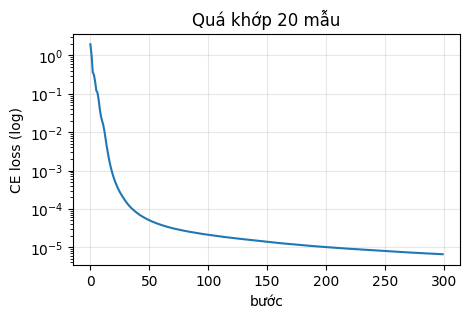

  W1 (net.0.weight) shape=(256, 54)    ‖grad‖ = 4.5429e-01
  b1 (net.0.bias  ) shape=(256,)       ‖grad‖ = 2.6839e-01
  W2 (net.2.weight) shape=(128, 256)   ‖grad‖ = 1.7565e+00
  b2 (net.2.bias  ) shape=(128,)       ‖grad‖ = 3.8244e-01
  W3 (net.4.weight) shape=(7, 128)     ‖grad‖ = 1.9387e+00
  b3 (net.4.bias  ) shape=(7,)         ‖grad‖ = 5.4980e-01


In [4]:
# Quá khớp 20 mẫu (dropout tắt, Adam lr 1e-2, 300 bước). Ảnh này chỉ hiện inline, không ghi vào figures/.
set_seed(0)
m20 = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
opt20 = torch.optim.Adam(m20.parameters(), lr=1e-2)
X20, y20 = data["X_tr"][:20], data["y_tr"][:20]
curve = []
for step in range(300):
    m20.train()
    loss = compute_loss(m20(X20), y20, "ce")
    opt20.zero_grad(); loss.backward(); opt20.step()
    curve.append(loss.item())
acc20 = (predict(m20, X20) == y20).float().mean().item()
print(f"20 mẫu: loss đầu = {curve[0]:.4f}, loss cuối = {curve[-1]:.2e}, accuracy = {acc20:.2f}")
plt.figure(figsize=(5, 3)); plt.semilogy(curve); plt.xlabel("bước"); plt.ylabel("CE loss (log)")
plt.title("Quá khớp 20 mẫu"); plt.grid(alpha=.3); plt.show()
assert curve[-1] < 1e-2 and acc20 == 1.0

# Gradient chảy tới mọi tham số?
model.zero_grad()
compute_loss(model(data["X_tr"][:512]), data["y_tr"][:512], "ce").backward()
names = ["W1", "b1", "W2", "b2", "W3", "b3"]
for n, (pn, p) in zip(names, model.named_parameters()):
    print(f"  {n} ({pn:12s}) shape={tuple(p.shape)!s:12s} ‖grad‖ = {p.grad.norm().item():.4e}")
assert all(p.grad is not None and p.grad.norm() > 0 for p in model.parameters())

**Nhận xét Part 1:** loss bước 0 = 2,207 (seed 0) và 2,269 (seed 1, dùng ở mọi thí nghiệm), cao hơn ln 7 = 1,946 khoảng 0,26–0,32.
Lý do: He (Var = 2/n_in) cũng được áp cho lớp ra nên logit có std ≈ 0,58 (bảng 3.7) thay vì ≈ 0; softmax không còn đều nên CE
bước 0 > ln 7. Đây là mức lệch vừa phải (bảng triệu chứng: "loss bước 0 cao hơn ln 7 nhiều" → giảm tỉ lệ W lớp cuối); với `normal`
0,01 logit ≈ 0 và loss bước 0 = 1,9460 đúng bằng ln 7, chứng tỏ cách tính loss không có lỗi. Quá khớp 20 mẫu: loss 1,97 → 6,6e-6 sau 300
bước, accuracy 100% ⇒ pipeline (nhãn, loss, optimizer, zero_grad) đúng. Mọi tham số W1..b3 có ‖grad‖ khác 0 (0,27 → 1,94).

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` là hàm huấn luyện duy nhất; mọi thí nghiệm chỉ đổi dict `cfg`. Mỗi epoch ghi: train loss (chế độ eval,
tập con cố định 50 000 mẫu train), val loss/acc/macro-F1, `grad_norm` trước clip (TB và max), tỉ lệ bước bị clip, thời gian
(có `cuda.synchronize`), bộ nhớ cực đại, loss bước 0, best epoch theo val loss, cờ diverged.

**Chọn lr cho baseline (chỉ dùng val):** SGD+momentum 0,9 với lr ∈ {0,01; 0,03; 0,1; 0,3}, seed 1, 20 epoch. Chọn lr có
**val macro-F1 cao nhất** (ở best epoch). Các lần chạy này cũng là phần "SGD+momentum" của chủ đề bộ tối ưu.

*Dự đoán:* lr 0,01 hội tụ chậm (20 epoch chưa đủ); 0,3 có thể dao động mạnh vì momentum 0,9 khiến bước hiệu dụng ≈ lr/(1−μ) = 3;
lr tốt nhất nằm khoảng 0,03–0,1.

[cache] opt-sgdm-lr0.01: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/opt-sgdm-lr0.01.json
[cache] opt-sgdm-lr0.03: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/opt-sgdm-lr0.03.json
[cache] opt-sgdm-lr0.1: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/opt-sgdm-lr0.1.json
[cache] opt-sgdm-lr0.3: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/opt-sgdm-lr0.3.json


,opt,lr,batch,hidden,drop,clip,prec,init,loss,step0,best_ep,best_val_loss,train_loss,val_loss,val_acc,val_f1,t_epoch,mem_MB,gn_p50,clip_frac,diverged
exp_id,,,,,,,,,,,,,,,,,,,,,
opt-sgdm-lr0.01,sgd_momentum,0.0100,512,256-128,0.0000,None,fp32,he,ce,2.2691,20,0.3106,0.2990,0.3106,0.8758,0.7615,1.2260,173.1226,0.9986,0.0000,False
opt-sgdm-lr0.03,sgd_momentum,0.0300,512,256-128,0.0000,None,fp32,he,ce,2.2691,18,0.2672,0.2507,0.2690,0.8933,0.8240,1.2084,173.1226,0.8904,0.0000,False
opt-sgdm-lr0.1,sgd_momentum,0.1000,512,256-128,0.0000,None,fp32,he,ce,2.2691,18,0.2332,0.2153,0.2365,0.9069,0.8410,1.2142,173.1226,0.5495,0.0000,False
opt-sgdm-lr0.3,sgd_momentum,0.3000,512,256-128,0.0000,None,fp32,he,ce,2.2691,20,0.2221,0.1950,0.2221,0.9109,0.8599,1.1901,173.1226,0.3461,0.0000,False


==> lr baseline (chọn theo val macro-F1): 0.3


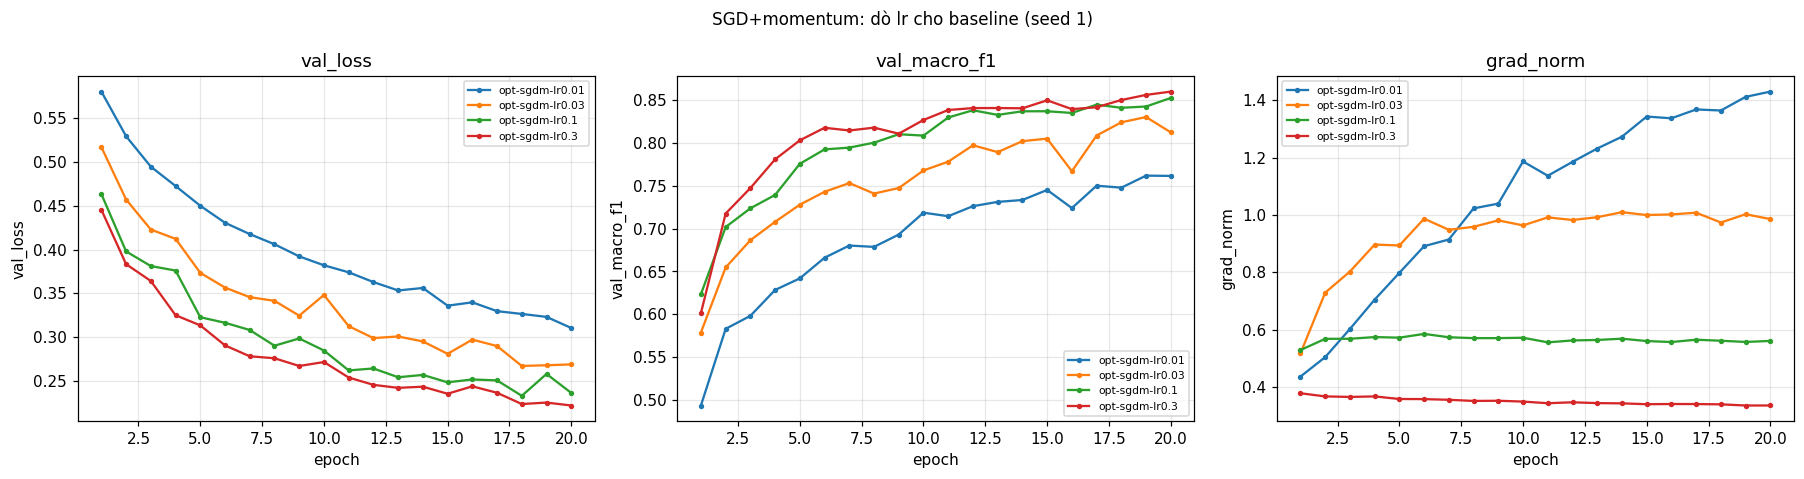

In [5]:
EPOCHS = 2 if QUICK else 20
BASE = {**DEFAULT_CFG, "epochs": EPOCHS}
ALL = {}            # exp_id -> result (thứ tự = thứ tự dòng trong bảng)
NOTES = {}          # exp_id -> ghi chú (dự đoán / quan sát) cho cột notes

def run(exp_id, group, description, note="", ckpt=False, **changes):
    cfg = {**BASE, **changes, "exp_id": exp_id, "group": group, "description": description}
    r = run_cached(cfg, data, RES, CKPT_DIR if ckpt else None, force=FORCE_RERUN)
    plot_run(r, f"{FIG}/{exp_id}.png")
    ALL[exp_id] = r
    NOTES[exp_id] = note
    return r

def table(ids, ref=None):
    rows = []
    for i in ids:
        c, s = ALL[i]["cfg"], ALL[i]["summary"]
        rows.append(dict(exp_id=i, opt=c["optimizer"], lr=c["lr"], batch=c["batch"], hidden="-".join(map(str, c["hidden"])),
                         drop=c["dropout"], clip=c["clip_norm"], prec=c["precision"], init=c["init"], loss=c["loss"],
                         step0=s["step0_loss"], best_ep=s["best_epoch"], best_val_loss=s["best_val_loss"],
                         train_loss=s["final_train_loss"], val_loss=s["final_val_loss"], val_acc=s["val_acc"],
                         val_f1=s["val_macro_f1"], t_epoch=s["time_per_epoch_s"], mem_MB=s["peak_mem_MB"],
                         gn_p50=s["grad_norm_p50"], clip_frac=s["clip_frac"], diverged=s["diverged"]))
    df = pd.DataFrame(rows).set_index("exp_id")
    if ref is not None:
        df["Δf1_vs_base"] = df["val_f1"] - ref["f1_mean"]
        df["vượt 2σ?"] = df["Δf1_vs_base"].abs() > ref["f1_2sigma"]
    with pd.option_context("display.float_format", "{:.4f}".format, "display.width", 250, "display.max_columns", 30):
        display(df)
    return df

LR_GRID_SGDM = [0.01, 0.03, 0.1, 0.3]
for lr in LR_GRID_SGDM:
    run(f"opt-sgdm-lr{lr:g}", "optimizer", f"SGD+momentum 0.9, lr={lr:g} (dò lr cho baseline)", lr=lr,
        note="Dò lr baseline. Dự đoán: 0.01 chậm, 0.3 dao động, tốt nhất ~0.03-0.1.")
sweep = table([f"opt-sgdm-lr{lr:g}" for lr in LR_GRID_SGDM])
BASE_LR = float(sweep["val_f1"].idxmax().split("lr")[1])
BASE["lr"] = BASE_LR
print(f"==> lr baseline (chọn theo val macro-F1): {BASE_LR:g}")
plot_compare([ALL[f"opt-sgdm-lr{lr:g}"] for lr in LR_GRID_SGDM], ["val_loss", "val_macro_f1", "grad_norm"],
             f"{FIG}/compare_baseline_lr.png", "SGD+momentum: dò lr cho baseline (seed 1)")
display(Image(f"{FIG}/compare_baseline_lr.png"))

**Baseline 3 seed** (seed 1, 2, 3) ở lr đã chọn để đo độ nhiễu. Ngưỡng nhiễu = 2σ của val macro-F1 giữa các seed.
Trọng số tốt nhất (theo val loss) của baseline được lưu để dự đoán eval ở Part 4.

[cache] base-s1: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/base-s1.json
[cache] base-s2: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/base-s2.json
[cache] base-s3: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/base-s3.json


,opt,lr,batch,hidden,drop,clip,prec,init,loss,step0,best_ep,best_val_loss,train_loss,val_loss,val_acc,val_f1,t_epoch,mem_MB,gn_p50,clip_frac,diverged
exp_id,,,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.3000,512,256-128,0.0000,None,fp32,he,ce,2.2691,20,0.2221,0.1950,0.2221,0.9109,0.8599,1.2058,173.1226,0.3461,0.0000,False
base-s2,sgd_momentum,0.3000,512,256-128,0.0000,None,fp32,he,ce,1.9782,19,0.2215,0.1952,0.2229,0.9129,0.8537,1.2162,173.1226,0.3411,0.0000,False
base-s3,sgd_momentum,0.3000,512,256-128,0.0000,None,fp32,he,ce,1.9005,19,0.2193,0.1993,0.2263,0.9123,0.8603,1.2159,173.1226,0.3438,0.0000,False


Baseline val macro-F1 = 0.8580 ± 0.0037 | val acc = 0.9120 ± 0.0010 | best val loss = 0.2210 ± 0.0015
==> Ngưỡng nhiễu 2σ (val macro-F1) = 0.0074


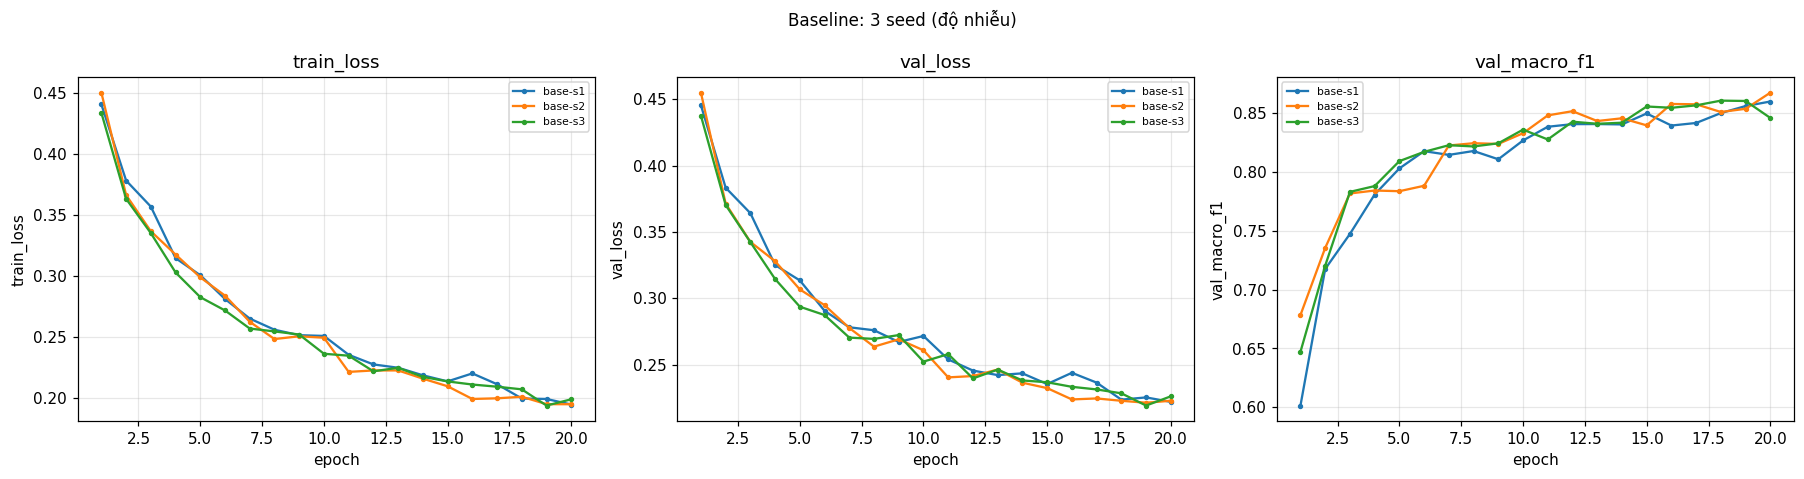

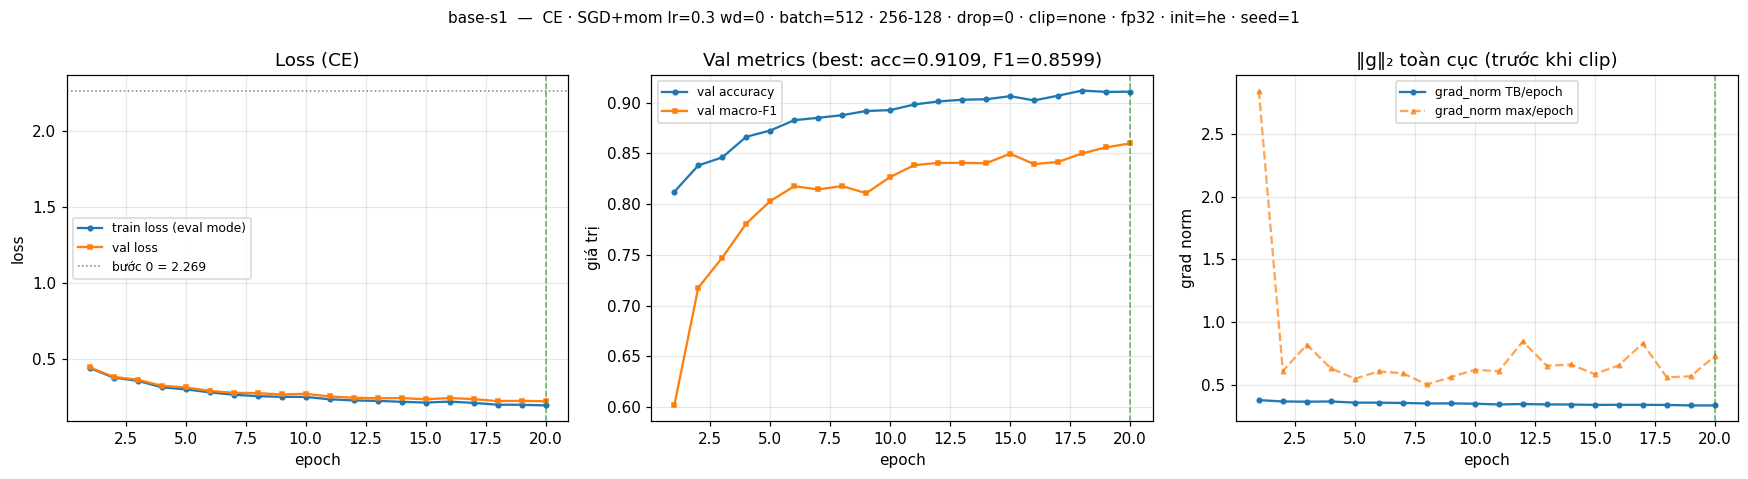

In [6]:
SEEDS = [1, 2, 3]
for s in SEEDS:
    run(f"base-s{s}", "baseline", f"Baseline M-base, seed {s}", seed=s, ckpt=True,
        note="Baseline. Dự đoán: val acc >> 0.4876, đường cong còn giảm ở epoch 20 (chưa quá khớp).")
base_ids = [f"base-s{s}" for s in SEEDS]
bt = table(base_ids)
REF = dict(f1_mean=bt["val_f1"].mean(), f1_std=bt["val_f1"].std(ddof=1), acc_mean=bt["val_acc"].mean(),
           acc_std=bt["val_acc"].std(ddof=1), loss_mean=bt["best_val_loss"].mean(), loss_std=bt["best_val_loss"].std(ddof=1))
REF["f1_2sigma"] = 2 * REF["f1_std"]
print("Baseline val macro-F1 = %.4f ± %.4f | val acc = %.4f ± %.4f | best val loss = %.4f ± %.4f" %
      (REF["f1_mean"], REF["f1_std"], REF["acc_mean"], REF["acc_std"], REF["loss_mean"], REF["loss_std"]))
print("==> Ngưỡng nhiễu 2σ (val macro-F1) = %.4f" % REF["f1_2sigma"])
assert all(ALL[i]["summary"]["val_acc"] > MAJ_ACC for i in base_ids)
plot_compare([ALL[i] for i in base_ids], ["train_loss", "val_loss", "val_macro_f1"], f"{FIG}/compare_baseline.png",
             "Baseline: 3 seed (độ nhiễu)")
display(Image(f"{FIG}/compare_baseline.png")); display(Image(f"{FIG}/base-s1.png"))

**Nhận xét baseline:** lr 0,3 cho val macro-F1 cao nhất trong lưới (0,7615 / 0,8240 / 0,8410 / 0,8599 cho 0,01 / 0,03 / 0,1 / 0,3), nên baseline dùng lr = 0,3.
Lưu ý: lr tốt nhất nằm ở **biên** lưới, nên có thể lr lớn hơn còn tốt hơn (hạn chế). Baseline 3 seed: val macro-F1 = 0,8580 ± 0,0037,
val acc = 0,9120 ± 0,0010, best val loss = 0,2210 ± 0,0015 ⇒ **ngưỡng nhiễu 2σ = 0,0074** (val macro-F1). Accuracy 0,91 ≫ 0,4876.
Hình dạng đường cong (`base-s1.png`): val loss giảm đều 0,445 → 0,222 trong 20 epoch, best epoch 19–20, train loss (eval mode) 0,195;
khoảng cách val − train chỉ 0,027 và cả hai còn giảm ⇒ **chưa hội tụ, chưa quá khớp** (thiếu thời gian/năng lực, không phải quá khớp).

## Part 3 — Thí nghiệm
Mỗi thí nghiệm: dự đoán trước → đổi một yếu tố so với `base-s1` (seed 1, cùng lr, 20 epoch) → chạy → đối chiếu, so với ngưỡng 2σ.

### 3.1 Hàm mất mát — CE vs MSE (`loss`)
MSE = `F.mse_loss(logits, one_hot(y))`, trung bình trên mọi phần tử B×7, không có hệ số 1/2.

**Dự đoán:** với CE, ∂L/∂z = softmax(z) − y: khi dự đoán sai nặng gradient vẫn lớn (≈ 1). MSE trên logit có ∂L/∂z = 2(z − y)/7 và
bị chia thêm cho 7 vì lấy trung bình trên 7 cột ⇒ gradient nhỏ hơn nhiều ở cùng lr ⇒ học chậm hơn, macro-F1 thấp hơn rõ, nhất là ở lớp hiếm.
Thử thêm MSE với lr ×3 để xem chênh lệch có phải chỉ do thang gradient. Không so giá trị loss (khác thang đo), chỉ so acc/macro-F1.

[cache] loss-mse: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/loss-mse.json
[cache] loss-mse-lr3x: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/loss-mse-lr3x.json


,opt,lr,batch,hidden,drop,clip,prec,init,loss,step0,best_ep,best_val_loss,train_loss,val_loss,val_acc,val_f1,t_epoch,mem_MB,gn_p50,clip_frac,diverged,Δf1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.3000,512,256-128,0.0000,None,fp32,he,ce,2.2691,20,0.2221,0.1950,0.2221,0.9109,0.8599,1.2058,173.1226,0.3461,0.0000,False,0.0019,False
loss-mse,sgd_momentum,0.3000,512,256-128,0.0000,None,fp32,he,mse,0.6359,20,0.0275,0.0265,0.0275,0.8801,0.7649,1.2799,173.1260,0.0649,0.0000,False,-0.0930,True
loss-mse-lr3x,sgd_momentum,0.9000,512,256-128,0.0000,None,fp32,he,mse,0.6359,19,0.0324,0.0355,0.0360,0.8599,0.7317,1.2852,173.1260,0.0647,0.0000,False,-0.1262,True


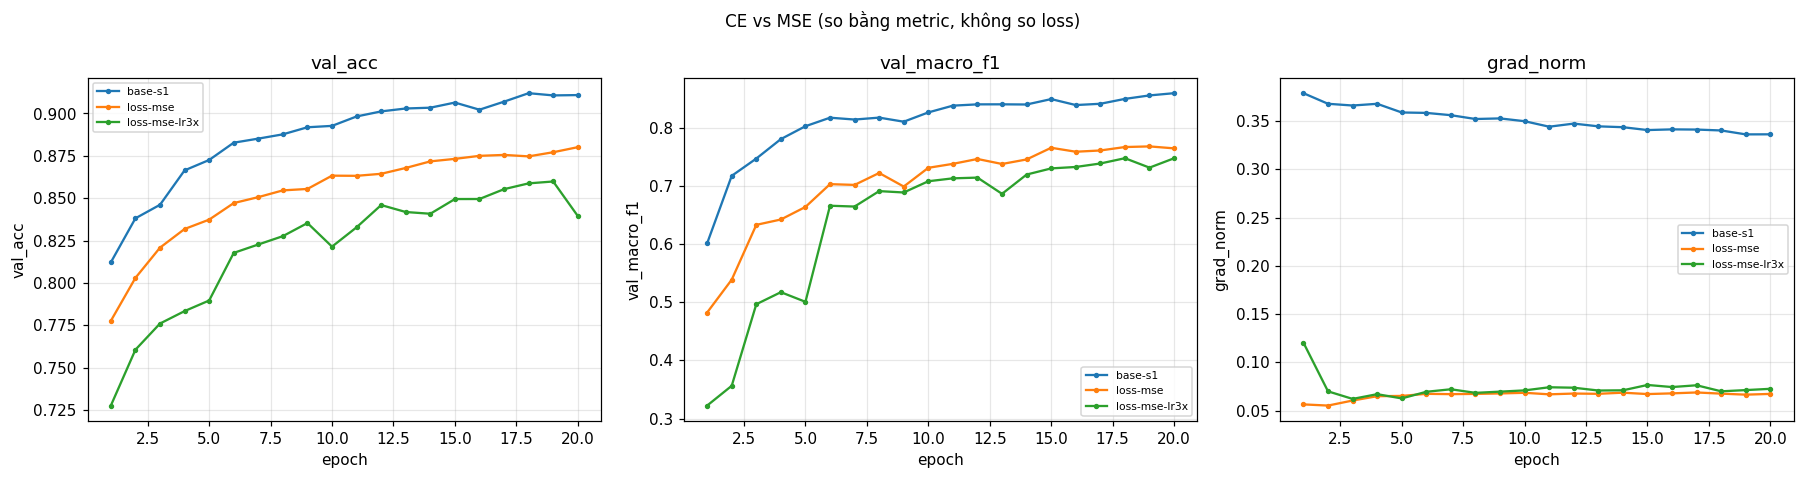

In [7]:
run("loss-mse", "loss", "MSE trên one-hot thay cho CE (cùng lr)", loss="mse",
    note="Dự đoán: gradient nhỏ hơn CE -> học chậm, F1 thấp hơn.")
run("loss-mse-lr3x", "loss", "MSE, lr x3 so với baseline (đổi 2 yếu tố: loss + lr)", loss="mse", lr=3 * BASE_LR,
    note="Kiểm tra: tăng lr có bù được gradient nhỏ của MSE không. Đổi 2 yếu tố.")
table(["base-s1", "loss-mse", "loss-mse-lr3x"], REF)
plot_compare([ALL[i] for i in ["base-s1", "loss-mse", "loss-mse-lr3x"]], ["val_acc", "val_macro_f1", "grad_norm"],
             f"{FIG}/compare_loss.png", "CE vs MSE (so bằng metric, không so loss)")
display(Image(f"{FIG}/compare_loss.png"))

**Đối chiếu 3.1:** MSE kém hơn CE rõ rệt: `loss-mse` val macro-F1 0,7649 (Δ = −0,093 ≫ 2σ), acc 0,8801 so với 0,9120. Khớp dự đoán.
grad_norm trung vị của MSE chỉ 0,065 so với 0,346 của CE (gấp ~5 lần nhỏ hơn): gradient MSE theo logit là 2(z − y)/(7·B), không có
cơ chế "sai càng nặng gradient càng lớn" như softmax − y của CE, và bị chia thêm 7. **Bất ngờ:** tăng lr ×3 (`loss-mse-lr3x`) không bù được
mà còn tệ hơn (0,7317) và grad_norm max tăng lên 11,8 ⇒ không chỉ là vấn đề thang gradient; với lr 0,9 + momentum, MSE trên logit không chặn
bị dao động. Thấp nhất vẫn là các lớp hiếm (macro-F1 giảm nhiều hơn accuracy).

### 3.2 Bộ tối ưu hoá (`optimizer`)
SGD (không momentum) lr ∈ {0,03; 0,1; 0,3}; Adam lr ∈ {3e-4; 1e-3; 3e-3} (betas 0,9/0,999, eps 1e-8); AdamW cùng lưới lr, weight_decay 0,01.
SGD+momentum đã có ở Part 2. So mỗi bộ ở **lr tốt nhất của nó** (theo val macro-F1).

**Dự đoán:** SGD thuần cần lr lớn hơn SGD+momentum ~10 lần (momentum 0,9 khuếch đại bước ≈ 10×) và vẫn chậm nhất;
Adam/AdamW nhanh ở vài epoch đầu nhờ bước chuẩn hoá theo từng tham số, ở lr tốt nhất có thể nhỉnh hơn SGD+momentum.
AdamW và Adam gần như bằng nhau (wd 0,01 nhỏ, mô hình chưa quá khớp) — khác biệt có lẽ nằm trong nhiễu.

[cache] opt-sgd-lr0.03: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/opt-sgd-lr0.03.json
[cache] opt-sgd-lr0.1: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/opt-sgd-lr0.1.json
[cache] opt-sgd-lr0.3: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/opt-sgd-lr0.3.json
[cache] opt-adam-lr0.0003: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/opt-adam-lr0.0003.json
[cache] opt-adam-lr0.001: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/opt-adam-lr0.001.json
[cache] opt-adam-lr0.003: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/opt-adam-lr0.003.json
[cache] opt-adamw-lr0.0003: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/opt-adamw-lr0.0003.json
[cache] opt-adamw-lr0.001: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/opt-adamw-lr0.001.json
[cache] opt-adamw-lr0.003: nạp lại /content/drive/MyDriv

,opt,lr,batch,hidden,drop,clip,prec,init,loss,step0,best_ep,best_val_loss,train_loss,val_loss,val_acc,val_f1,t_epoch,mem_MB,gn_p50,clip_frac,diverged,Δf1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,,,,,
opt-sgdm-lr0.01,sgd_momentum,0.0100,512,256-128,0.0000,None,fp32,he,ce,2.2691,20,0.3106,0.2990,0.3106,0.8758,0.7615,1.2260,173.1226,0.9986,0.0000,False,-0.0964,True
opt-sgdm-lr0.03,sgd_momentum,0.0300,512,256-128,0.0000,None,fp32,he,ce,2.2691,18,0.2672,0.2507,0.2690,0.8933,0.8240,1.2084,173.1226,0.8904,0.0000,False,-0.0339,True
opt-sgdm-lr0.1,sgd_momentum,0.1000,512,256-128,0.0000,None,fp32,he,ce,2.2691,18,0.2332,0.2153,0.2365,0.9069,0.8410,1.2142,173.1226,0.5495,0.0000,False,-0.0170,True
opt-sgdm-lr0.3,sgd_momentum,0.3000,512,256-128,0.0000,None,fp32,he,ce,2.2691,20,0.2221,0.1950,0.2221,0.9109,0.8599,1.1901,173.1226,0.3461,0.0000,False,0.0019,False
opt-sgd-lr0.03,sgd,0.0300,512,256-128,0.0000,None,fp32,he,ce,2.2691,19,0.4349,0.4412,0.4475,0.8142,0.6578,1.1865,172.9395,0.6503,0.0000,False,-0.2002,True
opt-sgd-lr0.1,sgd,0.1000,512,256-128,0.0000,None,fp32,he,ce,2.2691,18,0.3479,0.4575,0.4676,0.8568,0.7531,1.1777,172.9395,0.8162,0.0000,False,-0.1048,True
opt-sgd-lr0.3,sgd,0.3000,512,256-128,0.0000,None,fp32,he,ce,2.2691,18,0.2850,0.3494,0.3635,0.8838,0.8090,1.1577,172.9395,0.6204,0.0000,False,-0.0490,True
opt-adam-lr0.0003,adam,0.0003,512,256-128,0.0000,None,fp32,he,ce,2.2691,20,0.3139,0.3038,0.3139,0.8728,0.7874,1.3498,173.3057,0.7493,0.0000,False,-0.0705,True
opt-adam-lr0.001,adam,0.0010,512,256-128,0.0000,None,fp32,he,ce,2.2691,20,0.2472,0.2268,0.2472,0.9014,0.8476,1.3427,173.3057,0.8514,0.0000,False,-0.0103,True


Lr tốt nhất của từng bộ tối ưu (theo val macro-F1): {'sgd_momentum': 'opt-sgdm-lr0.3', 'sgd': 'opt-sgd-lr0.3', 'adam': 'opt-adam-lr0.003', 'adamw': 'opt-adamw-lr0.003'}


,opt,lr,batch,hidden,drop,clip,prec,init,loss,step0,best_ep,best_val_loss,train_loss,val_loss,val_acc,val_f1,t_epoch,mem_MB,gn_p50,clip_frac,diverged,Δf1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,,,,,
opt-sgdm-lr0.3,sgd_momentum,0.3000,512,256-128,0.0000,None,fp32,he,ce,2.2691,20,0.2221,0.1950,0.2221,0.9109,0.8599,1.1901,173.1226,0.3461,0.0000,False,0.0019,False
opt-sgd-lr0.3,sgd,0.3000,512,256-128,0.0000,None,fp32,he,ce,2.2691,18,0.2850,0.3494,0.3635,0.8838,0.8090,1.1577,172.9395,0.6204,0.0000,False,-0.0490,True
opt-adam-lr0.003,adam,0.0030,512,256-128,0.0000,None,fp32,he,ce,2.2691,18,0.2142,0.1891,0.2153,0.9138,0.8660,1.3542,173.3057,0.6444,0.0000,False,0.0081,True
opt-adamw-lr0.003,adamw,0.0030,512,256-128,0.0000,None,fp32,he,ce,2.2691,19,0.2231,0.2007,0.2234,0.9095,0.8615,1.3644,173.3057,0.6221,0.0000,False,0.0035,False


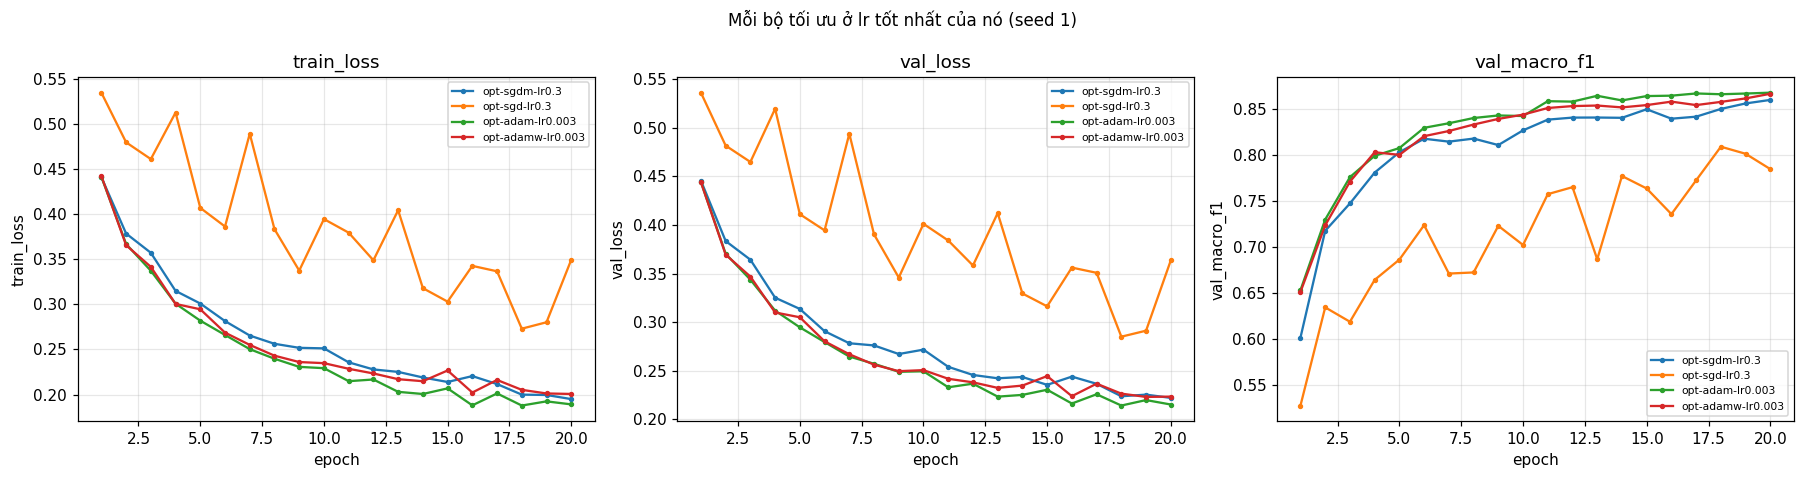

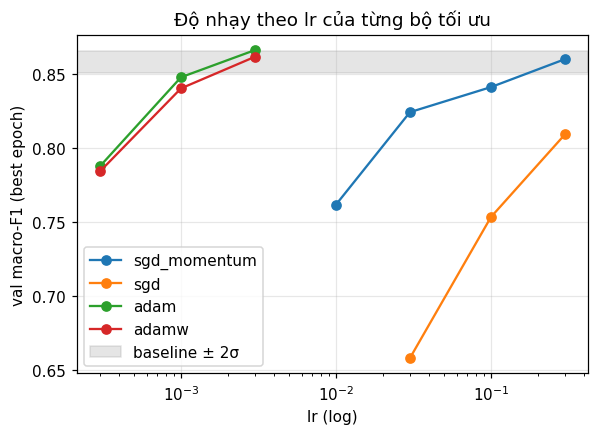

In [8]:
OPT_GRID = {"sgd": [0.03, 0.1, 0.3], "adam": [3e-4, 1e-3, 3e-3], "adamw": [3e-4, 1e-3, 3e-3]}
TAG = {"sgd": "sgd", "sgd_momentum": "sgdm", "adam": "adam", "adamw": "adamw"}
for opt, lrs in OPT_GRID.items():
    for lr in lrs:
        wd = 0.01 if opt == "adamw" else 0.0
        run(f"opt-{TAG[opt]}-lr{lr:g}", "optimizer", f"{opt}, lr={lr:g}, weight_decay={wd:g}", optimizer=opt, lr=lr,
            weight_decay=wd, note=f"Dự đoán: {'SGD thuần chậm hơn SGD+momentum' if opt == 'sgd' else 'Adam-family nhanh ở epoch đầu'}.")
opt_ids = {"sgd_momentum": [f"opt-sgdm-lr{lr:g}" for lr in LR_GRID_SGDM],
           **{o: [f"opt-{TAG[o]}-lr{lr:g}" for lr in lrs] for o, lrs in OPT_GRID.items()}}
ot = table([i for ids in opt_ids.values() for i in ids], REF)
BEST_OPT = {o: max(ids, key=lambda i: ALL[i]["summary"]["val_macro_f1"]) for o, ids in opt_ids.items()}
print("Lr tốt nhất của từng bộ tối ưu (theo val macro-F1):", BEST_OPT)
table(list(BEST_OPT.values()), REF)
plot_compare([ALL[i] for i in BEST_OPT.values()], ["train_loss", "val_loss", "val_macro_f1"],
             f"{FIG}/compare_optimizer.png", "Mỗi bộ tối ưu ở lr tốt nhất của nó (seed 1)")
fig, ax = plt.subplots(figsize=(6, 4))
for o, ids in opt_ids.items():
    ax.semilogx([ALL[i]["cfg"]["lr"] for i in ids], [ALL[i]["summary"]["val_macro_f1"] for i in ids], "o-", label=o)
ax.axhspan(REF["f1_mean"] - REF["f1_2sigma"], REF["f1_mean"] + REF["f1_2sigma"], color="gray", alpha=.2, label="baseline ± 2σ")
ax.set(xlabel="lr (log)", ylabel="val macro-F1 (best epoch)", title="Độ nhạy theo lr của từng bộ tối ưu"); ax.grid(alpha=.3); ax.legend()
fig.savefig(f"{FIG}/compare_optimizer_lr.png", dpi=110, bbox_inches="tight"); plt.close(fig)
display(Image(f"{FIG}/compare_optimizer.png")); display(Image(f"{FIG}/compare_optimizer_lr.png"))

**Đối chiếu 3.2:** Ở lr tốt nhất của mỗi bộ: Adam 3e-3 = 0,8660 (Δ = +0,008, vừa vượt 2σ = 0,0074, chỉ 1 seed), AdamW 3e-3 = 0,8615 (Δ = +0,0035, trong nhiễu),
SGD+momentum 0,3 = 0,8599 (chính là base-s1), SGD 0,3 = 0,8090 (Δ = −0,049). SGD thuần chậm nhất như dự đoán: không có momentum thì cùng lr
bước hiệu dụng nhỏ hơn ~10 lần (SGD lr 0,3 ≈ SGD+momentum lr 0,03 = 0,824). Adam/AdamW ít nhạy hơn khi đổi lr ×3 so với SGD ở đầu lưới,
nhưng **mọi bộ đều đạt tốt nhất ở lr lớn nhất của lưới** ⇒ kết luận "Adam thắng" chỉ đúng trong lưới này; mở rộng lưới có thể đổi thứ tự.
Nếu không chỉnh lr (ví dụ cùng lr 1e-3 cho mọi bộ), kết luận sẽ sai hoàn toàn. Adam vs AdamW (wd 0,01): khác biệt 0,0045 < 2σ, đúng dự đoán.

### 3.3 Hyper-parameter (`hparam`)
Batch 128 và 2048 (cùng lr ⇒ số bước/epoch lần lượt 2 906 và 182 so với 727); batch 2048 với lr ×4 (quy tắc tăng lr theo lô, không warmup — đổi 2 yếu tố);
độ rộng `M-wide` (512-256, 161 287 tham số); độ sâu `M-deep` (256-128-64, 55 687 tham số).

**Dự đoán:** cùng 20 epoch, batch 128 có gấp 4 số bước ⇒ val F1 cao hơn nhưng mỗi epoch chậm hơn nhiều (nhiều lần gọi kernel);
batch 2048 cùng lr có 1/4 số bước ⇒ kém hơn; tăng lr ×4 bù lại phần lớn. `M-wide` tăng năng lực ⇒ F1 cao hơn (mô hình đang chưa khớp);
`M-deep` thay đổi ít.

[cache] hp-batch128: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/hp-batch128.json
[cache] hp-batch2048: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/hp-batch2048.json
[cache] hp-batch2048-lr4x: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/hp-batch2048-lr4x.json
[cache] hp-wide: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/hp-wide.json
[cache] hp-deep: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/hp-deep.json


,opt,lr,batch,hidden,drop,clip,prec,init,loss,step0,best_ep,best_val_loss,train_loss,val_loss,val_acc,val_f1,t_epoch,mem_MB,gn_p50,clip_frac,diverged,Δf1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.3000,512,256-128,0.0000,None,fp32,he,ce,2.2691,20,0.2221,0.1950,0.2221,0.9109,0.8599,1.2058,173.1226,0.3461,0.0000,False,0.0019,False
hp-batch128,sgd_momentum,0.3000,128,256-128,0.0000,None,fp32,he,ce,2.2691,15,0.3159,0.3093,0.3320,0.8753,0.8035,4.7914,173.1021,0.4327,0.0000,False,-0.0545,True
hp-batch2048,sgd_momentum,0.3000,2048,256-128,0.0000,None,fp32,he,ce,2.2691,18,0.2381,0.2345,0.2544,0.9047,0.8420,0.3238,173.3662,0.4061,0.0000,False,-0.0159,True
hp-batch2048-lr4x,sgd_momentum,1.2000,2048,256-128,0.0000,None,fp32,he,ce,2.2691,11,1.2052,1.2036,1.2053,0.4876,0.0936,0.2934,173.3662,0.0229,0.0000,False,-0.7643,True
hp-wide,sgd_momentum,0.3000,512,512-256,0.0000,None,fp32,he,ce,1.9182,20,0.1993,0.1691,0.1993,0.9221,0.8721,1.2285,189.4790,0.3396,0.0000,False,0.0141,True
hp-deep,sgd_momentum,0.3000,512,256-128-64,0.0000,None,fp32,he,ce,1.9099,20,0.2210,0.1927,0.2210,0.9139,0.8588,1.3554,173.2388,0.3683,0.0000,False,0.0009,False


Số bước cập nhật mỗi epoch: {'base-s1': 727, 'hp-batch128': 2906, 'hp-batch2048': 182, 'hp-batch2048-lr4x': 182, 'hp-wide': 727, 'hp-deep': 727}


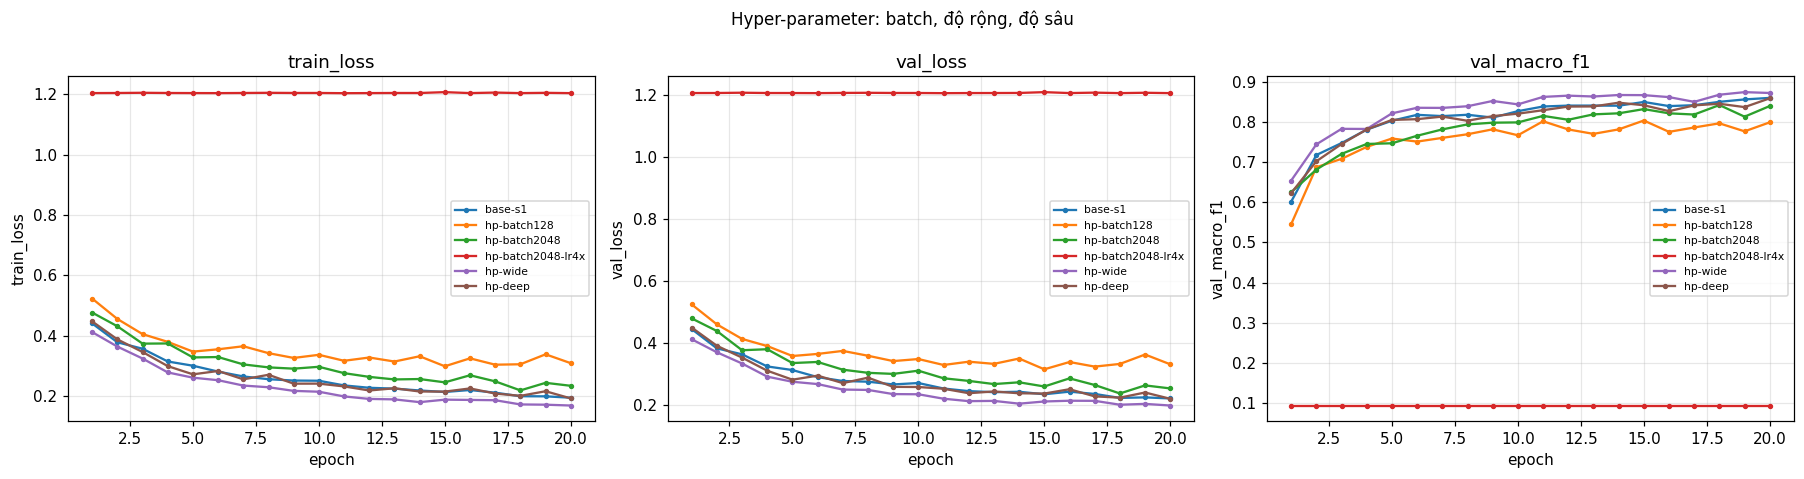

In [9]:
run("hp-batch128", "hparam", "batch 128 (cùng lr)", batch=128, note="Dự đoán: nhiều bước hơn -> F1 cao hơn, chậm hơn/epoch.")
run("hp-batch2048", "hparam", "batch 2048 (cùng lr)", batch=2048, note="Dự đoán: ít bước -> F1 thấp hơn.")
run("hp-batch2048-lr4x", "hparam", "batch 2048, lr x4 (linear scaling; đổi 2 yếu tố)", batch=2048, lr=4 * BASE_LR,
    note="Dự đoán: lr x4 bù phần lớn số bước bị mất.")
run("hp-wide", "hparam", "M-wide 512-256", hidden=(512, 256), note="Dự đoán: tăng năng lực -> F1 cao hơn.")
run("hp-deep", "hparam", "M-deep 256-128-64", hidden=(256, 128, 64), note="Dự đoán: thay đổi nhỏ.")
hp_ids = ["base-s1", "hp-batch128", "hp-batch2048", "hp-batch2048-lr4x", "hp-wide", "hp-deep"]
ht = table(hp_ids, REF)
print("Số bước cập nhật mỗi epoch:", {i: ALL[i]["summary"]["steps_per_epoch"] for i in hp_ids})
plot_compare([ALL[i] for i in hp_ids], ["train_loss", "val_loss", "val_macro_f1"], f"{FIG}/compare_hparam.png",
             "Hyper-parameter: batch, độ rộng, độ sâu")
display(Image(f"{FIG}/compare_hparam.png"))

**Đối chiếu 3.3:** **Batch 128 (cùng lr 0,3) kém hơn: 0,8035 (Δ = −0,054)**, ngược dự đoán: dù có 2 906 bước/epoch (×4), lr 0,3 với lô nhỏ cho nhiễu gradient lớn
(η/B tăng ×4), best epoch 15 rồi val loss tăng; mỗi epoch chậm 4,79 s so với 1,21 s. Batch 2048 (182 bước/epoch) = 0,8420 (Δ = −0,016): ít bước hơn
⇒ học chậm hơn, như dự đoán, và nhanh nhất (0,32 s/epoch). **Bất ngờ:** batch 2048 + lr ×4 = 1,2 (quy tắc tăng lr theo lô, không warmup) **sụp**
về dự đoán lớp đa số (acc 0,4876, F1 0,094, val loss 1,205 = entropy phân bố lớp) ⇒ thiếu warmup, bước đầu quá lớn. M-wide = 0,8721 (Δ = +0,014 > 2σ):
mô hình đang chưa khớp nên thêm năng lực giúp. M-deep = 0,8588 (Δ ≈ 0, trong nhiễu).

### 3.4 Dropout (`dropout`)
q ∈ {0,1; 0,3; 0,5}, đặt sau ReLU của 2 lớp ẩn. Train loss đo ở chế độ eval nên so sánh được với val.

**Dự đoán:** baseline gần như chưa quá khớp (khoảng cách val − train loss nhỏ, cả hai còn giảm ở epoch 20) nên dropout không giúp,
q càng lớn càng làm chậm học ⇒ val F1 giảm dần theo q; khoảng cách train–val co lại nhưng vì train loss tăng lên chứ không phải val giảm.

[cache] drop-0.1: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/drop-0.1.json
[cache] drop-0.3: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/drop-0.3.json
[cache] drop-0.5: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/drop-0.5.json


,opt,lr,batch,hidden,drop,clip,prec,init,loss,step0,best_ep,best_val_loss,train_loss,val_loss,val_acc,val_f1,t_epoch,mem_MB,gn_p50,clip_frac,diverged,Δf1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.3000,512,256-128,0.0000,None,fp32,he,ce,2.2691,20,0.2221,0.1950,0.2221,0.9109,0.8599,1.2058,173.1226,0.3461,0.0000,False,0.0019,False
drop-0.1,sgd_momentum,0.3000,512,256-128,0.1000,None,fp32,he,ce,2.2691,20,0.2398,0.2248,0.2398,0.9024,0.8339,1.3224,173.1479,0.2905,0.0000,False,-0.0241,True
drop-0.3,sgd_momentum,0.3000,512,256-128,0.3000,None,fp32,he,ce,2.2691,20,0.3165,0.3107,0.3165,0.8705,0.7820,1.3187,173.1479,0.2807,0.0000,False,-0.0760,True
drop-0.5,sgd_momentum,0.3000,512,256-128,0.5000,None,fp32,he,ce,2.2691,20,0.4198,0.4165,0.4198,0.8250,0.6699,1.3346,173.1479,0.2875,0.0000,False,-0.1881,True


Khoảng cách val − train loss (epoch cuối): {'base-s1': 0.0271, 'drop-0.1': 0.015, 'drop-0.3': 0.0058, 'drop-0.5': 0.0032}


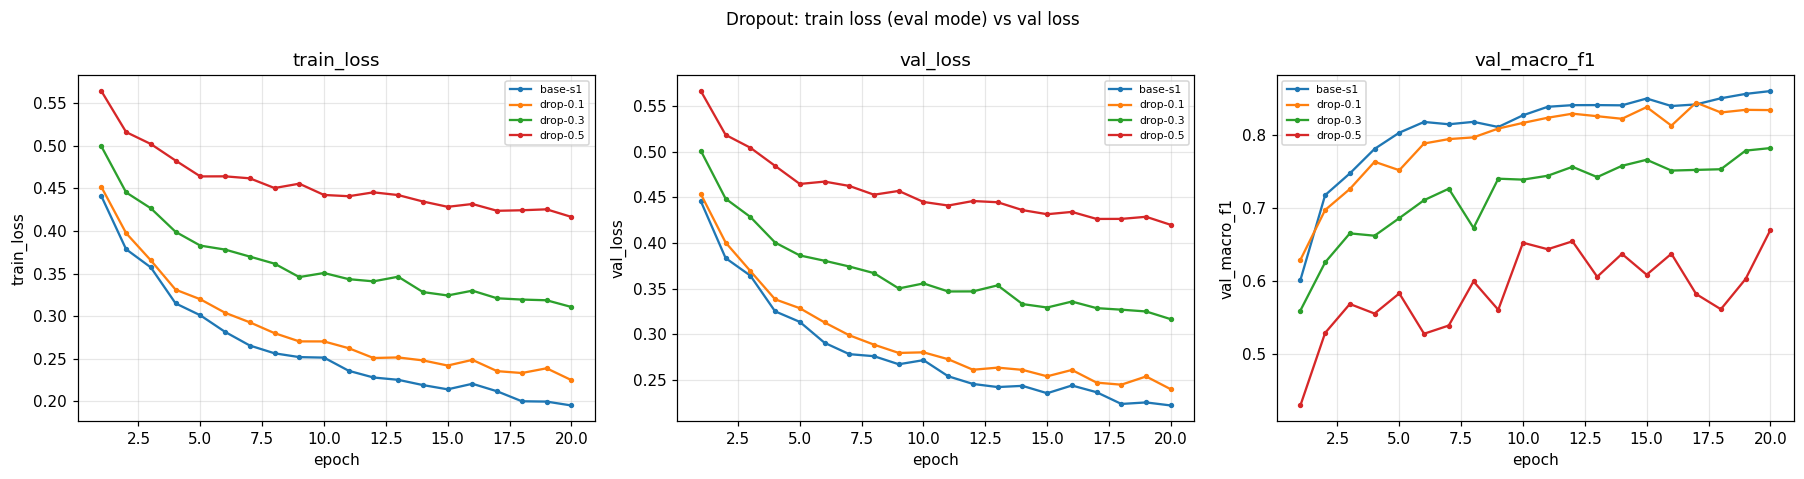

In [10]:
for q in [0.1, 0.3, 0.5]:
    run(f"drop-{q:g}", "dropout", f"dropout q={q:g} sau mỗi ReLU", dropout=q,
        note="Dự đoán: mô hình chưa quá khớp -> dropout không giúp, F1 giảm theo q.")
drop_ids = ["base-s1", "drop-0.1", "drop-0.3", "drop-0.5"]
dt = table(drop_ids, REF)
print("Khoảng cách val − train loss (epoch cuối):", {i: round(ALL[i]["summary"]["final_val_loss"] - ALL[i]["summary"]["final_train_loss"], 4) for i in drop_ids})
plot_compare([ALL[i] for i in drop_ids], ["train_loss", "val_loss", "val_macro_f1"], f"{FIG}/compare_dropout.png",
             "Dropout: train loss (eval mode) vs val loss")
display(Image(f"{FIG}/compare_dropout.png"))

**Đối chiếu 3.4:** Đúng dự đoán: dropout làm **tệ hơn** và càng tệ khi q tăng: 0,8339 / 0,7820 / 0,6698 (q = 0,1 / 0,3 / 0,5; đều vượt 2σ theo chiều xấu).
Khoảng cách val − train loss giảm 0,027 → 0,015 → 0,006 → 0,003, nhưng vì cả train loss lẫn val loss đều tăng (val 0,222 → 0,240 → 0,317 → 0,420),
không phải vì val giảm. Baseline chưa quá khớp nên dropout chỉ bớt năng lực/làm chậm học; dropout là thuốc cho quá khớp (train thấp, val tăng dần),
nên chỉ dùng khi thấy triệu chứng đó, ví dụ khi huấn luyện lâu hơn nhiều với mạng lớn.

### 3.5 Gradient clipping (`clipping`)
Chọn `c` từ phân bố `grad_norm` theo bước của `base-s1`: `c` = trung vị (p50) ⇒ clipping kích hoạt ở ~một nửa số bước.
Thí nghiệm phản chứng: lr cao = 10 × lr baseline, **không clip** vs **có clip** (cùng `c`).

**Dự đoán:** ở lr bình thường, clip ở p50 chỉ làm bước nhỏ đi một chút ⇒ khác biệt nằm trong nhiễu (có thể hơi chậm hơn).
Ở lr ×10 không clip, SGD+momentum dao động mạnh/NaN (bước hiệu dụng rất lớn); có clip, độ dài bước bị chặn bởi lr·c nên huấn luyện
ổn định hơn, dù vẫn kém baseline.

grad_norm theo bước của base-s1: p50=0.346 p90=0.405 p99=0.487 max=2.844
[cache] clip-0.346: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/clip-0.346.json
[cache] clip-none-highlr: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/clip-none-highlr.json
[cache] clip-0.346-highlr: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/clip-0.346-highlr.json


,opt,lr,batch,hidden,drop,clip,prec,init,loss,step0,best_ep,best_val_loss,train_loss,val_loss,val_acc,val_f1,t_epoch,mem_MB,gn_p50,clip_frac,diverged,Δf1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.3000,512,256-128,0.0000,NaN,fp32,he,ce,2.2691,20,0.2221,0.1950,0.2221,0.9109,0.8599,1.2058,173.1226,0.3461,0.0000,False,0.0019,False
clip-0.346,sgd_momentum,0.3000,512,256-128,0.0000,0.3460,fp32,he,ce,2.2691,18,0.2269,0.2010,0.2291,0.9095,0.8469,1.2054,173.1479,0.3708,0.7186,False,-0.0110,True
clip-none-highlr,sgd_momentum,3.0000,512,256-128,0.0000,NaN,fp32,he,ce,2.2691,17,1.2090,1.2083,1.2101,0.4876,0.0936,1.2250,173.1479,0.0685,0.0000,False,-0.7643,True
clip-0.346-highlr,sgd_momentum,3.0000,512,256-128,0.0000,0.3460,fp32,he,ce,2.2691,1,0.9413,0.9871,0.9949,0.5824,0.2616,1.2238,173.1479,0.1308,0.0352,False,-0.5964,True


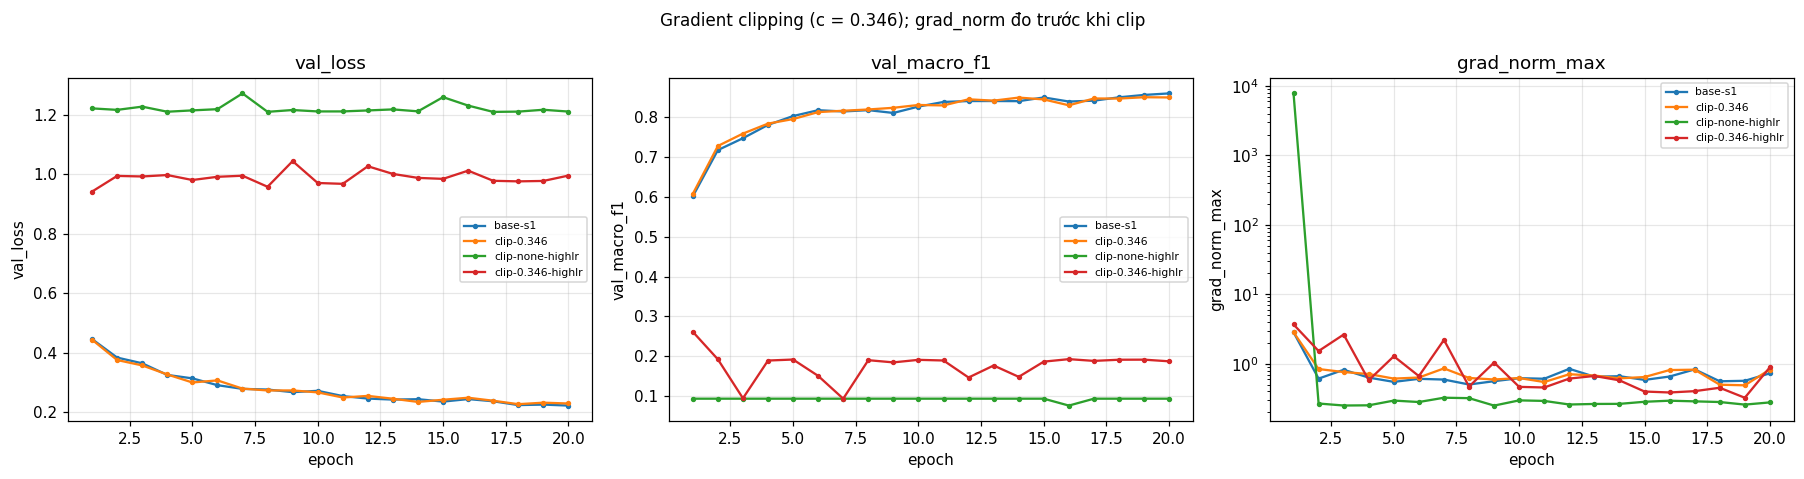

In [11]:
s1 = ALL["base-s1"]["summary"]
print("grad_norm theo bước của base-s1: p50=%.3f p90=%.3f p99=%.3f max=%.3f" %
      (s1["grad_norm_p50"], s1["grad_norm_p90"], s1["grad_norm_p99"], s1["grad_norm_max"]))
CLIP_C = round(s1["grad_norm_p50"], 3)
HIGH_LR = 10 * BASE_LR
run(f"clip-{CLIP_C:g}", "clipping", f"clip c={CLIP_C:g} (p50 grad_norm base-s1), lr baseline", clip_norm=CLIP_C,
    note="Dự đoán: ở lr thường khác biệt nằm trong nhiễu.")
run("clip-none-highlr", "clipping", f"lr x10 = {HIGH_LR:g}, không clip (đổi lr)", lr=HIGH_LR,
    note="Dự đoán: dao động mạnh hoặc NaN.")
run(f"clip-{CLIP_C:g}-highlr", "clipping", f"lr x10 = {HIGH_LR:g}, clip c={CLIP_C:g} (đổi lr + clip)", lr=HIGH_LR, clip_norm=CLIP_C,
    note="Dự đoán: clipping giữ huấn luyện ổn định ở lr cao.")
clip_ids = ["base-s1", f"clip-{CLIP_C:g}", "clip-none-highlr", f"clip-{CLIP_C:g}-highlr"]
table(clip_ids, REF)
plot_compare([ALL[i] for i in clip_ids], ["val_loss", "val_macro_f1", "grad_norm_max"], f"{FIG}/compare_clipping.png",
             f"Gradient clipping (c = {CLIP_C:g}); grad_norm đo trước khi clip")
display(Image(f"{FIG}/compare_clipping.png"))

**Đối chiếu 3.5:** grad_norm theo bước của base-s1: p50 = 0,346, p90 = 0,405, max = 2,84 (gai ở các bước đầu) ⇒ c = 0,346. Ở lr thường clipping kích hoạt ở 72% số bước
và làm val macro-F1 giảm 0,8469 (Δ = −0,011, vượt 2σ): cắt gần trung vị thực chất là giảm lr hiệu dụng, trong khi baseline đang thiếu bước.
**Phản chứng lr ×10 = 3:** không clip (`clip-none-highlr`) có gai grad_norm 7 814 ở epoch 1, sau đó mạng **sụp** về dự đoán hằng (val loss 1,21 ≈ entropy
phân bố lớp 1,205, F1 0,094, grad_norm chỉ còn ~0,27); loss không thành NaN nên cờ diverged = N, nhưng huấn luyện đã hỏng. Có clip (`clip-0.346-highlr`):
grad_norm max chỉ 3,7, mạng không sụp (F1 0,26 ở epoch 1, ~0,19 về sau), nhưng vẫn rất kém vì lr 3 quá lớn (bước bị chặn ở lr·c ≈ 1, momentum nhân thêm).
⇒ Clipping chặn được **gai gradient đột ngột** (mất 1 bước thay vì mất cả mạng) chứ không sửa được lr sai.

### 3.6 Mixed precision (`amp`)
FP16: `autocast(float16)` + `GradScaler` (luôn `unscale_` trước khi đo/clip gradient). BF16: `autocast(bfloat16)`, không GradScaler.
Tham số vẫn FP32. Thêm `M-wide` + FP16 để so với `hp-wide` (FP32) xem mạng lớn hơn có hưởng lợi không.

**Dự đoán:** T4 có Tensor Core FP16 nhưng mạng 48k tham số và batch 512 quá nhỏ: thời gian bị chi phối bởi chi phí gọi kernel và
các phép cast thêm ⇒ FP16 **không nhanh hơn**, có thể chậm hơn; bộ nhớ đỉnh gần như không đổi (dữ liệu FP32 trên GPU chiếm phần lớn).
T4 (Turing) không có phần cứng BF16 ⇒ BF16 chậm hơn hoặc báo không hỗ trợ. Độ chính xác giữ nguyên trong nhiễu.

torch.cuda.is_bf16_supported(): True | capability: (7, 5)
[cache] amp-fp16: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/amp-fp16.json
[cache] amp-bf16: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/amp-bf16.json
[cache] amp-fp16-wide: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/amp-fp16-wide.json


,opt,lr,batch,hidden,drop,clip,prec,init,loss,step0,best_ep,best_val_loss,train_loss,val_loss,val_acc,val_f1,t_epoch,mem_MB,gn_p50,clip_frac,diverged,Δf1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.3000,512,256-128,0.0000,None,fp32,he,ce,2.2691,20,0.2221,0.1950,0.2221,0.9109,0.8599,1.2058,173.1226,0.3461,0.0000,False,0.0019,False
amp-fp16,sgd_momentum,0.3000,512,256-128,0.0000,None,fp16,he,ce,2.2691,19,0.2310,0.2075,0.2328,0.9095,0.8552,1.7150,173.1470,0.3413,0.0000,False,-0.0028,False
amp-bf16,sgd_momentum,0.3000,512,256-128,0.0000,None,bf16,he,ce,2.2691,18,0.2295,0.2111,0.2355,0.9097,0.8506,1.4516,173.1460,0.3456,0.0000,False,-0.0074,False
hp-wide,sgd_momentum,0.3000,512,512-256,0.0000,None,fp32,he,ce,1.9182,20,0.1993,0.1691,0.1993,0.9221,0.8721,1.2285,189.4790,0.3396,0.0000,False,0.0141,True
amp-fp16-wide,sgd_momentum,0.3000,512,512-256,0.0000,None,fp16,he,ce,1.9182,18,0.2014,0.1716,0.2017,0.9205,0.8685,1.6677,189.4780,0.3401,0.0000,False,0.0106,True


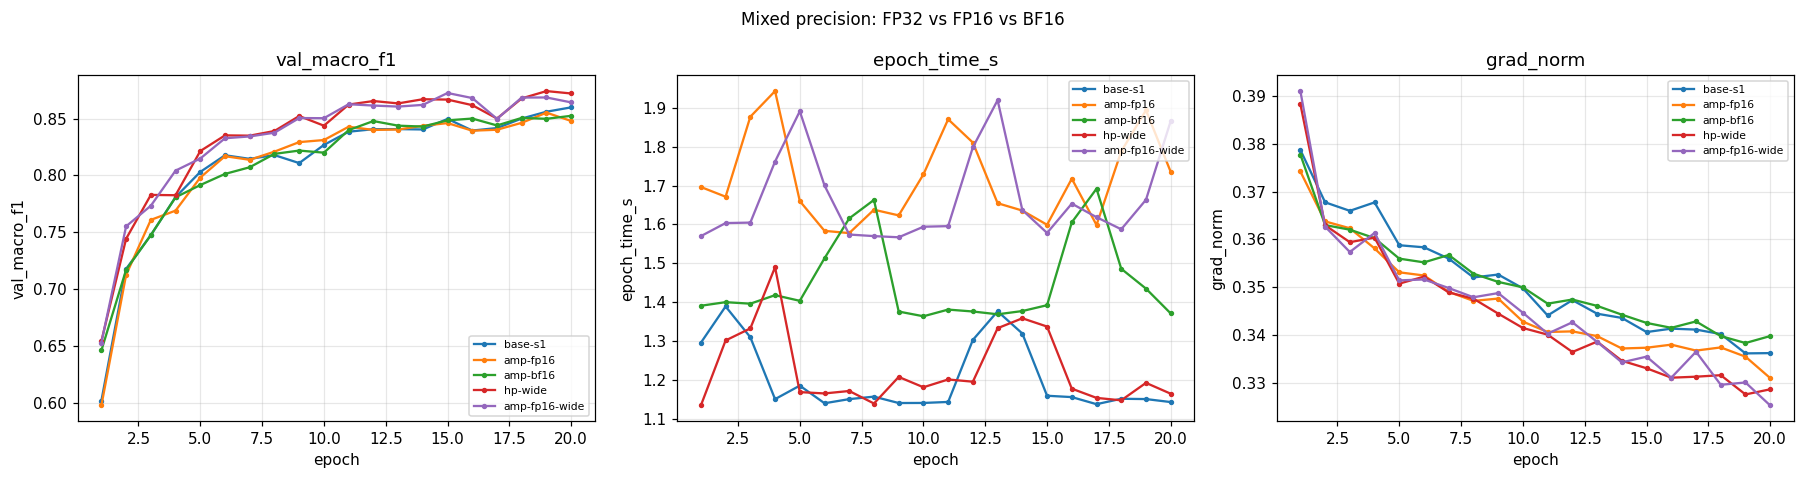

In [12]:
bf16_ok = device.type == "cuda" and torch.cuda.is_bf16_supported()
print("torch.cuda.is_bf16_supported():", bf16_ok, "| capability:", torch.cuda.get_device_capability(0) if device.type == "cuda" else None)
run("amp-fp16", "amp", "FP16 autocast + GradScaler", precision="fp16", note="Dự đoán: không nhanh hơn với mạng nhỏ.")
amp_ids = ["base-s1", "amp-fp16"]
try:
    run("amp-bf16", "amp", "BF16 autocast (không GradScaler)", precision="bf16",
        note=f"T4 không có BF16 phần cứng; is_bf16_supported={bf16_ok}.")
    amp_ids.append("amp-bf16")
except Exception as e:      # ghi lý do vào notes nếu GPU không chạy được BF16
    print("BF16 lỗi:", repr(e))
run("amp-fp16-wide", "amp", "M-wide + FP16 (so với hp-wide FP32; đổi 2 yếu tố)", precision="fp16", hidden=(512, 256),
    note="So với hp-wide: mạng rộng hơn có hưởng lợi từ FP16 không.")
amp_ids += ["hp-wide", "amp-fp16-wide"]
table(amp_ids, REF)
plot_compare([ALL[i] for i in amp_ids], ["val_macro_f1", "epoch_time_s", "grad_norm"], f"{FIG}/compare_amp.png",
             "Mixed precision: FP32 vs FP16 vs BF16")
display(Image(f"{FIG}/compare_amp.png"))

**Đối chiếu 3.6:** Đúng dự đoán: **FP16 chậm hơn** 1,72 s/epoch so với 1,21 s FP32 (+42%), BF16 1,45 s (+20%); bộ nhớ đỉnh như nhau (173 MB, phần lớn là dữ liệu FP32
nằm sẵn trên GPU). Với mạng 48k tham số, mỗi matmul quá nhỏ để Tensor Core có lợi; autocast thêm phép cast, GradScaler thêm unscale/kiểm tra inf mỗi bước ⇒
chi phí cố định mỗi bước tăng. Kể cả M-wide (161k tham số) FP16 vẫn chậm hơn (1,67 so với 1,23 s). Độ chính xác: FP16 0,8552 (Δ −0,003), BF16 0,8506
(|Δ| = 0,0074, sát ngưỡng 2σ; nhiều khả năng do BF16 chỉ có 8 bit mantissa) ⇒ không kết luận được là kém hơn. T4 (Turing, sm_75) không có phần cứng BF16;
PyTorch vẫn chạy được bằng giả lập. FP16 cần GradScaler vì khoảng biểu diễn hẹp (min normal ≈ 6e-5, max 65 504) dễ underflow gradient nhỏ; BF16 có cùng
khoảng số mũ với FP32 (≈ 1e-38 … 3e38) nên thường không cần nhân loss với s.

### 3.7 Khởi tạo tham số (`init`)
`zeros` (W = 0), `normal` (N(0, 0,01²)), `xavier` (`xavier_normal_`, Var = 2/(n_in+n_out)), `default` (mặc định `nn.Linear`:
U(±1/√n_in), Var = 1/(3·n_in)) so với `he` (baseline, Var = 2/n_in). Bias = 0 (trừ `default`).

**Dự đoán:** `zeros`: mọi nơ-ron ẩn ra ReLU(0) = 0 ⇒ gradient tới W1, W2 bằng 0 và các nơ-ron đối xứng ⇒ chỉ bias lớp cuối học được ⇒
mô hình chỉ học được tần suất lớp (acc ≈ 0,4876, F1 ≈ 0,094). `normal` 0,01: kích hoạt co lại ~×0,1 mỗi lớp ⇒ logit ≈ 0, loss bước 0 = ln 7 đúng,
nhưng gradient lớp đầu nhỏ ⇒ khởi động chậm, sau 20 epoch có thể bắt kịp một phần. `xavier`/`default` cho std kích hoạt giảm dần qua lớp nhưng
mạng chỉ 3 lớp nên khác biệt với He nhỏ, có thể nằm trong nhiễu.

Std kích hoạt ở bước 0 (một lô val 4096 mẫu), M-base:


,std ReLU1,std ReLU2,std logits,step0 val loss
zeros,0.0000,0.0000,0.0000,1.9459
normal,0.0203,0.0022,0.0003,1.9460
xavier,0.1628,0.1248,0.1916,2.0222
default,0.1603,0.0678,0.0585,1.9830
he,0.3901,0.3661,0.5773,2.2691


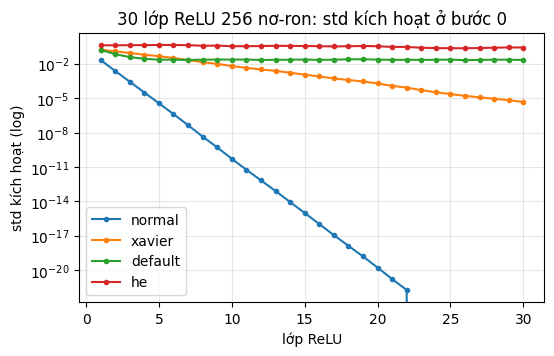

[cache] init-zeros: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/init-zeros.json
[cache] init-normal: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/init-normal.json
[cache] init-xavier: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/init-xavier.json
[cache] init-default: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/init-default.json


,opt,lr,batch,hidden,drop,clip,prec,init,loss,step0,best_ep,best_val_loss,train_loss,val_loss,val_acc,val_f1,t_epoch,mem_MB,gn_p50,clip_frac,diverged,Δf1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.3000,512,256-128,0.0000,None,fp32,he,ce,2.2691,20,0.2221,0.1950,0.2221,0.9109,0.8599,1.2058,173.1226,0.3461,0.0000,False,0.0019,False
init-zeros,sgd_momentum,0.3000,512,256-128,0.0000,None,fp32,zeros,ce,1.9459,16,1.2053,1.2045,1.2063,0.4876,0.0936,1.1889,180.4873,0.0335,0.0000,False,-0.7643,True
init-normal,sgd_momentum,0.3000,512,256-128,0.0000,None,fp32,normal,ce,1.9460,20,0.2195,0.1964,0.2195,0.9127,0.8558,1.2005,180.4873,0.3470,0.0000,False,-0.0022,False
init-xavier,sgd_momentum,0.3000,512,256-128,0.0000,None,fp32,xavier,ce,2.0222,20,0.2220,0.1966,0.2220,0.9125,0.8605,1.2361,180.4873,0.3488,0.0000,False,0.0025,False
init-default,sgd_momentum,0.3000,512,256-128,0.0000,None,fp32,default,ce,1.9830,20,0.2192,0.1933,0.2192,0.9145,0.8525,1.2161,180.4873,0.3459,0.0000,False,-0.0055,False


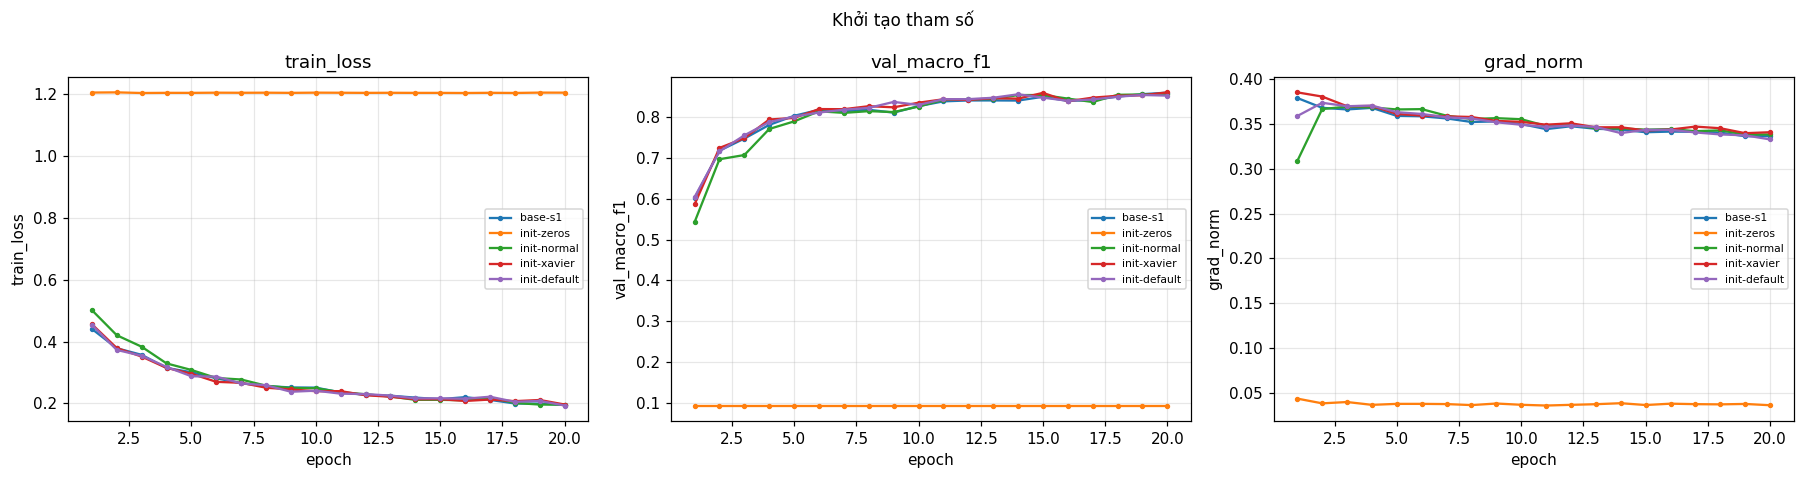

In [13]:
xb = data["X_val"][:4096]
rows = {}
for ini in ["zeros", "normal", "xavier", "default", "he"]:
    set_seed(1)
    m = MLP(hidden=(256, 128), init=ini).to(device)
    rows[ini] = activation_stats(m, xb) + [evaluate(m, data["X_val"], data["y_val"])["loss"]]
print("Std kích hoạt ở bước 0 (một lô val 4096 mẫu), M-base:")
display(pd.DataFrame(rows, index=["std ReLU1", "std ReLU2", "std logits", "step0 val loss"]).T.round(4))

# Minh hoạ "30 lớp ReLU" như slide: chỉ khởi tạo + forward, KHÔNG huấn luyện (không phải kiến trúc nộp).
deep = {}
for ini in ["normal", "xavier", "default", "he"]:
    set_seed(1)
    m = MLP(hidden=(256,) * 30, init=ini).to(device)
    deep[ini] = activation_stats(m, xb)[:-1]
fig, ax = plt.subplots(figsize=(6, 3.5))
for ini, v in deep.items():
    ax.semilogy(range(1, 31), v, "o-", ms=3, label=ini)
ax.set(xlabel="lớp ReLU", ylabel="std kích hoạt (log)", title="30 lớp ReLU 256 nơ-ron: std kích hoạt ở bước 0"); ax.grid(alpha=.3); ax.legend()
plt.show()

for ini in ["zeros", "normal", "xavier", "default"]:
    run(f"init-{ini}", "init", f"khởi tạo {ini} thay cho He", init=ini, note=f"Dự đoán: xem markdown 3.7 ({ini}).")
init_ids = ["base-s1", "init-zeros", "init-normal", "init-xavier", "init-default"]
table(init_ids, REF)
plot_compare([ALL[i] for i in init_ids], ["train_loss", "val_macro_f1", "grad_norm"], f"{FIG}/compare_init.png",
             "Khởi tạo tham số")
display(Image(f"{FIG}/compare_init.png"))

**Đối chiếu 3.7:** `zeros` hỏng đúng như dự đoán: loss bước 0 = 1,9459 = ln 7 (logit = 0), nhưng mọi kích hoạt ẩn = ReLU(0) = 0 ⇒ ∂L/∂W của mọi lớp = 0 và các nơ-ron
đối xứng; chỉ b3 học được ⇒ mô hình học đúng phân bố tiên nghiệm (val loss 1,205 = entropy lớp, acc 0,4876, F1 0,094). `normal` 0,01: std kích hoạt
0,020 → 0,0022 → logit 0,0003 (co ~×10 mỗi lớp), loss bước 0 = 1,946; vẫn học được (0,8558, trong nhiễu) vì mạng chỉ 3 lớp và SGD+momentum lr 0,3 kéo
trọng số ra khỏi vùng nhỏ. `xavier` 0,8605, `default` 0,8525: đều trong nhiễu 2σ so với He. **3 lớp không đủ sâu để thấy khác biệt khi huấn luyện**;
minh hoạ 30 lớp (chỉ forward) thì rõ: std ở lớp 30: normal → 0 (tràn dưới, < 1e-20 từ lớp 22), xavier 4,6e-6, default 0,021 (bias ngẫu nhiên giữ mức), he 0,25
(gần như không đổi). He bù hệ số 1/2 của ReLU (Var = 2/n_in) nên phương sai được giữ qua các lớp; Xavier (2/(n_in+n_out), cho tanh/tuyến tính) thiếu
hệ số 2 đó nên co dần ~×0,7 mỗi lớp — quan trọng với mạng sâu.

## Part 4 — Cấu hình cuối, đánh giá trên eval, bảng
### 4.1 Chọn cấu hình cuối (chỉ bằng val; quy tắc viết TRƯỚC khi xem kết quả)
1. Bộ tối ưu + lr: lần chạy có val macro-F1 cao nhất trong nhóm `optimizer`.
2. Kiến trúc: `M-wide` hoặc `M-deep` nếu val macro-F1 của nó > trung bình baseline + 2σ (chọn cái cao hơn), ngược lại `M-base`.
3. Dropout: q tốt nhất nếu vượt baseline + 2σ, ngược lại 0. Batch, clipping, precision, init giữ như baseline
   (chỉ đổi nếu vượt 2σ: batch 128 nếu `hp-batch128` vượt).
4. Huấn luyện **40 epoch** (baseline chưa hội tụ ở epoch 20); best epoch chọn theo val loss (tương đương dừng sớm).
5. Chạy 3 seed; nộp dự đoán của seed có **val macro-F1 cao nhất**.

Eval chỉ chạy đúng 2 lần: `base-s1` và cấu hình cuối. Không chỉnh gì sau khi xem điểm eval.

Tối ưu tốt nhất: opt-adam-lr0.003 | kiến trúc vượt 2σ: ['hp-wide'] | dropout vượt 2σ: [] | batch128 vượt 2σ: False
==> Cấu hình cuối (thay đổi so với baseline): {'optimizer': 'adam', 'lr': 0.003, 'weight_decay': 0.0, 'hidden': (512, 256), 'epochs': 40}
[cache] final-s1: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/final-s1.json
[cache] final-s2: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/final-s2.json
[cache] final-s3: nạp lại /content/drive/MyDrive/lab_day1/submission_2A202602715/results/final-s3.json


,opt,lr,batch,hidden,drop,clip,prec,init,loss,step0,best_ep,best_val_loss,train_loss,val_loss,val_acc,val_f1,t_epoch,mem_MB,gn_p50,clip_frac,diverged,Δf1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,,,,,
final-s1,adam,0.0030,512,512-256,0.0000,None,fp32,he,ce,1.9182,39,0.1611,0.1061,0.1615,0.9396,0.9042,1.3795,197.4341,0.5176,0.0000,False,0.0463,True
final-s2,adam,0.0030,512,512-256,0.0000,None,fp32,he,ce,2.6520,37,0.1610,0.1179,0.1670,0.9397,0.9091,1.3796,197.4341,0.5607,0.0000,False,0.0511,True
final-s3,adam,0.0030,512,512-256,0.0000,None,fp32,he,ce,2.7882,40,0.1568,0.1073,0.1568,0.9415,0.9105,1.3783,197.4341,0.5349,0.0000,False,0.0525,True


Cấu hình cuối val macro-F1 = 0.9079 ± 0.0033 (baseline 0.8580 ± 0.0037)
==> Nộp dự đoán của final-s3 (val macro-F1 cao nhất trong 3 seed)


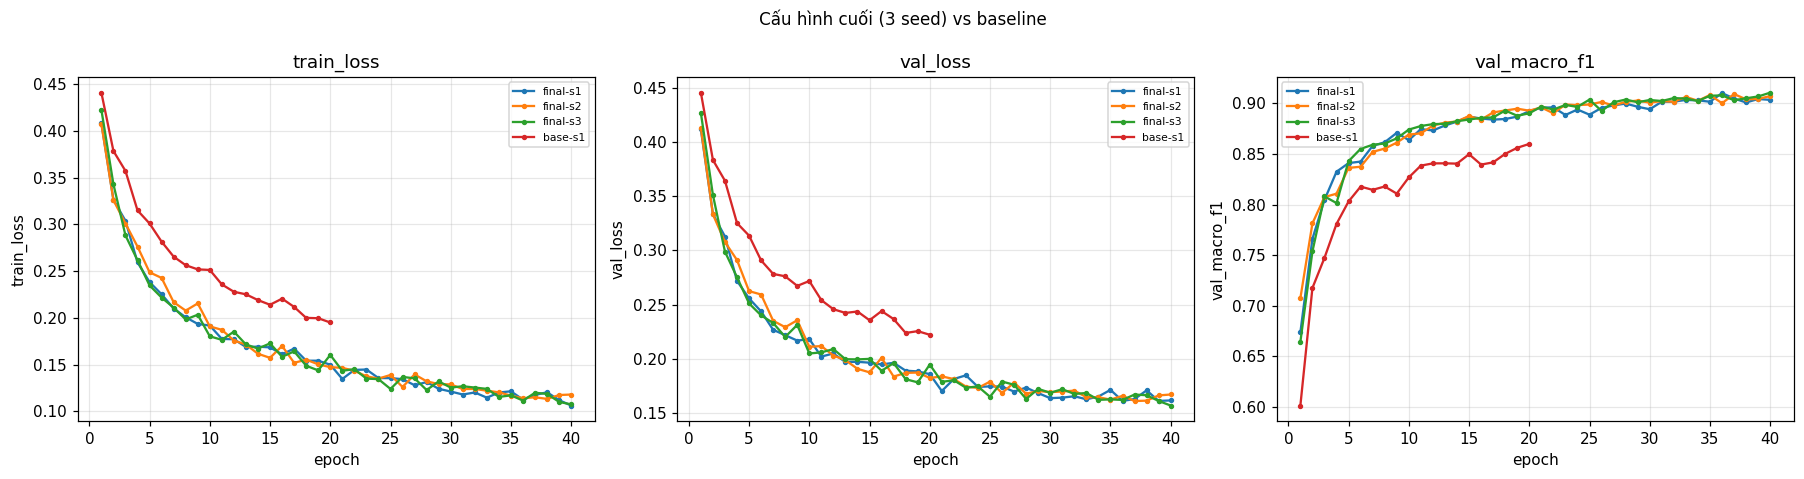

In [14]:
def beats(i):
    return ALL[i]["summary"]["val_macro_f1"] > REF["f1_mean"] + REF["f1_2sigma"]

best_opt_id = max(opt_ids_all := [i for ids in opt_ids.values() for i in ids], key=lambda i: ALL[i]["summary"]["val_macro_f1"])
bo = ALL[best_opt_id]["cfg"]
FINAL = dict(optimizer=bo["optimizer"], lr=bo["lr"], weight_decay=bo["weight_decay"])
arch = [i for i in ("hp-wide", "hp-deep") if beats(i)]
if arch:
    FINAL["hidden"] = tuple(ALL[max(arch, key=lambda i: ALL[i]["summary"]["val_macro_f1"])]["cfg"]["hidden"])
dropc = [i for i in ("drop-0.1", "drop-0.3", "drop-0.5") if beats(i)]
if dropc:
    FINAL["dropout"] = ALL[max(dropc, key=lambda i: ALL[i]["summary"]["val_macro_f1"])]["cfg"]["dropout"]
if beats("hp-batch128"):
    FINAL["batch"] = 128
FINAL["epochs"] = 2 if QUICK else 40
print("Tối ưu tốt nhất:", best_opt_id, "| kiến trúc vượt 2σ:", arch, "| dropout vượt 2σ:", dropc,
      "| batch128 vượt 2σ:", beats("hp-batch128"))
print("==> Cấu hình cuối (thay đổi so với baseline):", FINAL)

desc = "Cấu hình cuối: " + ", ".join(f"{k}={v}" for k, v in FINAL.items())
for s in SEEDS:
    run(f"final-s{s}", "final", desc + f", seed {s}", seed=s, ckpt=True, **FINAL,
        note="Cấu hình cuối chọn theo val (quy tắc 4.1).")
final_ids = [f"final-s{s}" for s in SEEDS]
ft = table(final_ids, REF)
FINAL_F1 = (ft["val_f1"].mean(), ft["val_f1"].std(ddof=1))
print("Cấu hình cuối val macro-F1 = %.4f ± %.4f (baseline %.4f ± %.4f)" % (*FINAL_F1, REF["f1_mean"], REF["f1_std"]))
SUBMIT_ID = ft["val_f1"].idxmax()
print("==> Nộp dự đoán của", SUBMIT_ID, "(val macro-F1 cao nhất trong 3 seed)")
plot_compare([ALL[i] for i in final_ids] + [ALL["base-s1"]], ["train_loss", "val_loss", "val_macro_f1"],
             f"{FIG}/compare_final.png", "Cấu hình cuối (3 seed) vs baseline")
display(Image(f"{FIG}/compare_final.png"))

### 4.2 Đánh giá trên eval (`scripts/evaluate.py`)
Baseline (`base-s1`) ghi ra `predictions_eval_baseline.csv` / `eval_result_baseline.json` (chỉ để so sánh);
cấu hình cuối ghi ra `predictions_eval.csv` / `eval_result.json` (file nộp).

In [15]:
EVAL_BASE = final_eval(ALL["base-s1"]["cfg"], ALL["base-s1"], data, f"{OUT_DIR}/predictions_eval_baseline.csv",
                       repo_root=REPO_ROOT, out_json=f"{OUT_DIR}/eval_result_baseline.json")
EVAL_FINAL = final_eval(ALL[SUBMIT_ID]["cfg"], ALL[SUBMIT_ID], data, f"{OUT_DIR}/predictions_eval.csv",
                        repo_root=REPO_ROOT, out_json=f"{OUT_DIR}/eval_result.json")
pred = pd.read_csv(f"{OUT_DIR}/predictions_eval.csv")
assert list(pred.columns) == ["row_id", "pred"] and len(pred) == 116_203 and pred["row_id"].is_unique
print(pd.DataFrame({"base-s1": [ALL["base-s1"]["summary"]["val_macro_f1"], EVAL_BASE["macro_f1"], EVAL_BASE["accuracy"]],
                    SUBMIT_ID: [ALL[SUBMIT_ID]["summary"]["val_macro_f1"], EVAL_FINAL["macro_f1"], EVAL_FINAL["accuracy"]]},
                   index=["val macro-F1", "eval macro-F1", "eval accuracy"]).round(4))

n_eval = 116203
accuracy = 0.9105
macro_f1 = 0.8609   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9172  0.8994  0.9082
  1    56661     0.9213  0.9279  0.9246
  2     7151     0.8786  0.9290  0.9031
  3      549     0.9037  0.7177  0.8000
  4     1899     0.6964  0.8273  0.7562
  5     3473     0.8722  0.7642  0.8146
  6     4102     0.8991  0.9408  0.9195

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  38106   3784     0    0    87     4   387
1   3198  52576   176    1   572    92    46
2      5    197  6643   22    18   266     0
3      1      0   138  394     0    16     0
4     27    262    28    0  1571    11     0
5     12    205   576   19     7  2654     0
6    196     46     0    0     1     0  3859

đã ghi /content/drive/MyDrive/lab_day1/submission_2A202602715/eval_result_baseline.json
 
n_eval = 116203
accuracy = 0.9413
macro_f1 = 0.9135   <- chỉ số chính

lớp  support  precision  recall    f1
  0

,support,precision,recall,f1,train_count
cls,,,,,
0,42368,0.9427,0.9335,0.9381,135578
1,56661,0.9479,0.9517,0.9498,181312
2,7151,0.9455,0.9357,0.9405,22882
3,549,0.8092,0.9271,0.8642,1759
4,1899,0.8443,0.8710,0.8574,6075
5,3473,0.8927,0.9033,0.8980,11115
6,4102,0.9374,0.9564,0.9468,13126


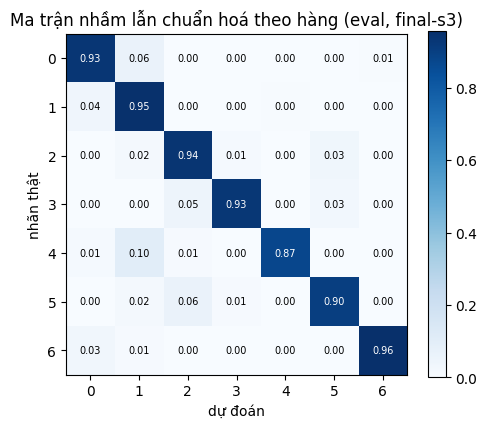

Lớp khó nhất: 4 (F1 = 0.8574); bị nhầm nhiều nhất sang lớp 1 (195/1899 = 10.3%)


,lớp 4,lớp 1
Elevation,-0.611,-0.137
Aspect,-0.147,-0.033
Slope,0.350,-0.075
H_Dist_Hydro,-0.266,0.048
V_Dist_Hydro,0.071,-0.009
H_Dist_Road,-0.643,0.052
Hillshade_9am,0.427,0.066
Hillshade_Noon,-0.216,0.103
Hillshade_3pm,-0.543,0.010
H_Dist_Fire,-0.304,0.143


In [16]:
# Phân tích lỗi theo lớp (eval, cấu hình cuối) + số mẫu train từng lớp để lý giải
pc = pd.DataFrame(EVAL_FINAL["per_class"]).set_index("cls")
pc["train_count"] = np.bincount(data["y_tr"].cpu().numpy(), minlength=7)
display(pc.round(4))
cm = np.array(EVAL_FINAL["confusion_matrix"])
cmn = cm / cm.sum(1, keepdims=True)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(cmn, cmap="Blues")
for i in range(7):
    for j in range(7):
        ax.text(j, i, f"{cmn[i, j]:.2f}", ha="center", va="center", fontsize=7, color="white" if cmn[i, j] > .5 else "black")
ax.set(xlabel="dự đoán", ylabel="nhãn thật", title=f"Ma trận nhầm lẫn chuẩn hoá theo hàng (eval, {SUBMIT_ID})")
plt.colorbar(im); plt.show()
hard = int(pc["f1"].idxmin())
off = cm[hard].copy(); off[hard] = 0
conf_with = int(off.argmax())
print(f"Lớp khó nhất: {hard} (F1 = {pc.loc[hard, 'f1']:.4f}); bị nhầm nhiều nhất sang lớp {conf_with} "
      f"({off[conf_with]}/{cm[hard].sum()} = {off[conf_with] / cm[hard].sum():.1%})")
# So sánh đặc trưng của 2 lớp hay nhầm (trên TRAIN, giá trị đã chuẩn hoá): 10 cột số
Xtr, ytr = data["X_tr"].cpu().numpy(), data["y_tr"].cpu().numpy()
names = ["Elevation", "Aspect", "Slope", "H_Dist_Hydro", "V_Dist_Hydro", "H_Dist_Road", "Hillshade_9am",
         "Hillshade_Noon", "Hillshade_3pm", "H_Dist_Fire"]
display(pd.DataFrame({f"lớp {c}": Xtr[ytr == c, :10].mean(0) for c in (hard, conf_with)}, index=names).round(3))

**Phân tích lỗi:** Cấu hình cuối (Adam lr 3e-3, M-wide, 40 epoch) val macro-F1 = 0,9079 ± 0,0033 (3 seed) so với baseline 0,8580 ± 0,0037 ⇒ +0,050 ≫ 2σ.
Nộp `final-s3` (val 0,9105). Eval: **macro-F1 = 0,9135, accuracy = 0,9413**; baseline `base-s1` trên eval: macro-F1 = 0,8609, acc = 0,9105 ⇒ cải thiện
+0,053. Val và eval rất gần (0,9105 vs 0,9135; 0,8599 vs 0,8609). **Lớp khó nhất: 4 (Aspen), F1 = 0,857**, 10,3% (195/1 899) bị nhầm sang lớp 1 (Lodgepole Pine).
Lý do: Aspen chỉ có ~6 100 mẫu train so với ~181 000 của lớp 1 (≈ 1:30), và hai lớp chồng lấn đặc trưng: cùng dải độ cao trung bình (mean chuẩn hoá −0,61
vs −0,14), Aspen gần đường hơn (H_Dist_Road −0,64) và có Hillshade_3pm thấp hơn; vùng chồng lấn bị lớp đông áp đảo. Lớp 3 (Cottonwood/Willow) có recall cao
(0,93) nhưng precision thấp (0,81): mô hình gán nhầm 84 mẫu Ponderosa Pine (lớp 2) và 36 Douglas-fir (lớp 5) sang lớp 3 — các lớp này cùng vùng hoang dã thấp.
Cách cải thiện sẽ thử: CE có trọng số theo lớp (hoặc lấy mẫu cân bằng) để đẩy biên quyết định về phía lớp hiếm, chọn theo val macro-F1.

### 4.3 Bảng `experiments.xlsx`
Mỗi lần chạy một dòng (cùng thứ tự chạy), sheet `Seeds` = `base-s1..3`, `eval_acc`/`eval_macro_f1` chỉ cho `base-s1` và cấu hình nộp.

In [17]:
SUMMARY_NOTES = {    # nhận xét ngắn theo nhóm (viết sau khi có kết quả; số liệu ở REPORT.md)
    "baseline": "SGD+momentum lr 0.3 (chọn theo val, ở biên lưới). 3 seed: F1 0.8580 ± 0.0037 -> 2σ = 0.0074. Chưa hội tụ ở epoch 20.",
    "loss": "MSE kém CE rõ (-0.093); lr x3 không bù được. Gradient MSE nhỏ ~5 lần.",
    "optimizer": "Ở lr tốt nhất: Adam 0.866 > AdamW 0.862 ≈ SGDm 0.860 > SGD 0.809. Mọi bộ tốt nhất ở biên lưới lr; chỉ Adam vừa vượt 2σ.",
    "hparam": "M-wide +0.014 (vượt 2σ). Batch 128 cùng lr kém (-0.054); batch 2048 kém (-0.016); 2048 + lr x4 sụp. M-deep ≈ baseline.",
    "dropout": "Mô hình chưa quá khớp -> dropout làm tệ hơn, giảm theo q (0.834/0.782/0.670).",
    "clipping": "c = 0.346 (p50 grad_norm). Lr thường: clip 72% bước, -0.011. Lr x10: không clip sụp sau gai 7814; có clip không sụp nhưng vẫn kém.",
    "amp": "FP16 chậm hơn 42%, BF16 chậm hơn 20% (T4 không có BF16 phần cứng); độ chính xác trong nhiễu; bộ nhớ như nhau.",
    "init": "zeros hỏng (chỉ học phân bố lớp). normal/xavier/default trong nhiễu so với He ở mạng 3 lớp.",
    "final": "Adam 3e-3 + M-wide + 40 epoch: val F1 0.9079 ± 0.0033 (+0.050). Eval final-s3: F1 0.9135, acc 0.9413.",
}
OBS = {   # quan sát sau khi chạy, nối vào cột notes
    "opt-sgdm-lr0.3": "Quan sát: tốt nhất trong lưới (biên) -> lr baseline; trùng base-s1.",
    "base-s1": "Quan sát: val loss còn giảm ở epoch 20, gap val-train 0.027.",
    "loss-mse": "Quan sát: -0.093 so với baseline; grad_norm p50 0.065 vs 0.346.",
    "loss-mse-lr3x": "Quan sát: còn tệ hơn (0.732), grad_norm max 11.8.",
    "opt-adam-lr0.003": "Quan sát: tốt nhất trong nhóm, +0.008 (vừa vượt 2σ, 1 seed).",
    "hp-batch128": "Quan sát: ngược dự đoán, kém hơn (nhiễu gradient lớn ở lr 0.3), 4.8 s/epoch.",
    "hp-batch2048-lr4x": "Quan sát: sụp về lớp đa số (lr 1.2 không warmup).",
    "hp-wide": "Quan sát: +0.014, vượt 2σ -> dùng cho cấu hình cuối.",
    "clip-0.346": "Quan sát: clip 72% bước, -0.011.",
    "clip-none-highlr": "Quan sát: gai grad_norm 7814 ở epoch 1 rồi sụp về dự đoán hằng (loss 1.21), không NaN.",
    "clip-0.346-highlr": "Quan sát: không sụp nhưng F1 ~0.19-0.26; clip chặn gai nhưng không sửa lr quá lớn.",
    "amp-fp16": "Quan sát: chậm hơn FP32 42%, F1 trong nhiễu.",
    "amp-bf16": "Quan sát: chạy được (giả lập), chậm hơn 20%; |Δ| sát 2σ.",
    "init-zeros": "Quan sát: acc 0.4876, F1 0.094, loss = entropy lớp: chỉ b3 học.",
}
rows = []
for i, r in ALL.items():
    ev = EVAL_BASE if i == "base-s1" else EVAL_FINAL if i == SUBMIT_ID else None
    note = (NOTES.get(i, "") + " " + OBS.get(i, "")).strip()
    if i == SUBMIT_ID:
        note += " Đây là mô hình nộp (predictions_eval.csv)."
    rows.append(to_row(r, ev, note))
write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx",
           seed_ids=base_ids, summary_notes=SUMMARY_NOTES)
figs = sorted(f for f in os.listdir(FIG) if not f.startswith("compare_"))
assert len(figs) == len(rows) and set(figs) == {f"{r['exp_id']}.png" for r in rows}, "số ảnh phải bằng số dòng"
print(f"{len(rows)} dòng, {len(figs)} ảnh thí nghiệm, ảnh so sánh:", sorted(f for f in os.listdir(FIG) if f.startswith("compare_")))
print("Đã ghi", os.path.abspath(f"{OUT_DIR}/experiments.xlsx"))

39 dòng, 39 ảnh thí nghiệm, ảnh so sánh: ['compare_amp.png', 'compare_baseline.png', 'compare_baseline_lr.png', 'compare_clipping.png', 'compare_dropout.png', 'compare_final.png', 'compare_hparam.png', 'compare_init.png', 'compare_loss.png', 'compare_optimizer.png', 'compare_optimizer_lr.png']
Đã ghi /content/drive/MyDrive/lab_day1/submission_2A202602715/experiments.xlsx


### 4.4 Gom thư mục nộp trên Drive
Chép `REPORT.md` và các module `code/*.py` từ repo vào thư mục nộp trên Drive. `code/lab.ipynb` (có output) lấy bằng
*File → Download → .ipynb* rồi đặt vào `submission_2A202602715/code/`.

In [18]:
import shutil, glob
src_sub = f"{REPO_ROOT}/submission_{MSSV}"
if os.path.abspath(src_sub) != os.path.abspath(OUT_DIR):
    if os.path.exists(f"{src_sub}/REPORT.md"):
        shutil.copy(f"{src_sub}/REPORT.md", OUT_DIR)
    os.makedirs(f"{OUT_DIR}/code", exist_ok=True)
    for f in glob.glob(f"{src_sub}/code/*.py"):
        shutil.copy(f, f"{OUT_DIR}/code/")
for root, dirs, files in sorted(os.walk(OUT_DIR)):
    if "figures" in root or "results" in root:
        print(f"{os.path.relpath(root, OUT_DIR)}/  ({len(files)} files)"); continue
    for f in sorted(files):
        print(os.path.relpath(os.path.join(root, f), OUT_DIR))

REPORT.md
eval_result.json
eval_result_baseline.json
experiments.xlsx
predictions_eval.csv
predictions_eval_baseline.csv
code/data.py
code/model.py
code/optimizer.py
code/plots.py
code/results_table.py
code/train.py
figures/  (50 files)
results/  (39 files)
